In [1]:
from src.utils import read_obs
from anndata import read_h5ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np

/opt/conda/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


In [5]:
rna_obs = read_obs("/root/capsule/data/adata_1/CaH_filtered_nuclei.2026-07-22.h5ad")

In [7]:
spatial_obs = read_obs("/root/capsule/data/adata_1/CaH_Xenium_filtered.2026-07-23.h5ad")

In [ ]:
assert all([cluster_col in spatial_obs.columns for cluster_col in ["Neighborhood", "Subclass", "Supertype"]])

In [9]:
donors = set(spatial_obs['Donor ID']) & set(rna_obs['Donor ID'])

In [10]:
def get_conv_dict(obs, child, parent):
    if parent is None:
        return {cluster:"All" for cluster in obs[child].unique()}
    else:
        return obs.groupby(child)[parent].first().to_dict()

In [13]:
rna_obs_subset = rna_obs

In [17]:
rna_obs_subset.groupby(["Donor ID", "library_prep"])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()

/tmp/ipykernel_28391/1136000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rna_obs_subset.groupby(["Donor ID", "library_prep"])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()
/tmp/ipykernel_28391/1136000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rna_obs_subset.groupby(["Donor ID", "library_prep"])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()


Donor ID    Subclass            
H19.33.004  Astrocyte               0.002349
            CN LAMP5-CXCL14 GABA    0.000021
            CN ST18 GABA            0.001030
            Endothelial             0.000275
            Ependymal               0.000154
                                      ...   
H21.33.039  STR Hybrid MSN          0.000122
            STR RSPO2 GABA          0.000010
            Sst Chodl               0.000044
            VLMC                    0.000427
            Vip                     0.000018
Name: proportion, Length: 656, dtype: float64

In [ ]:
rna_obs_subset.groupby(["Donor ID", "library_prep"])[child_col].value_counts(normalize = True).reset_index().groupby(["Donor ID", child_col])["proportion"].mean()

In [22]:
spatial_obs.groupby(["Donor ID", 'barcode'])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()

/tmp/ipykernel_28391/720370835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby(["Donor ID", 'barcode'])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()
/tmp/ipykernel_28391/720370835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby(["Donor ID", 'barcode'])["Subclass"].value_counts(normalize = True).reset_index().groupby(["Donor ID", "Subclass"])['proportion'].mean()


Donor ID    Subclass            
H19.33.004  Astrocyte               0.015898
            CN LAMP5-CXCL14 GABA    0.000017
            CN ST18 GABA            0.001512
            Endothelial             0.011941
            Ependymal               0.000074
                                      ...   
H21.33.027  STR Hybrid MSN          0.001233
            STR RSPO2 GABA          0.000053
            Sst Chodl               0.000828
            VLMC                    0.013857
            Vip                     0.000243
Name: proportion, Length: 135, dtype: float64

In [42]:
rna_obs['Supertype'].isin(["Micro-PVM_2_3-SEAAD"]).mean()

np.float64(0.013924034036527646)

In [54]:
x.index.get_level_values("Supertype").nunique()

65

In [55]:
y.index.get_level_values("Supertype").nunique()

66

In [57]:
mask

Donor ID
H20.33.026    True
H20.33.001    True
H20.33.012    True
H20.33.031    True
H21.33.027    True
H21.33.004    True
H20.33.017    True
H19.33.004    True
H21.33.002    True
Name: proportion, dtype: bool

{('Immune', 'All'), ('CGE', 'All'), ('Vascular', 'All'), ('Astro-Epen', 'All'), ('LGE', 'All'), ('OPC-Oligo', 'All'), ('MGE', 'All')}


/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

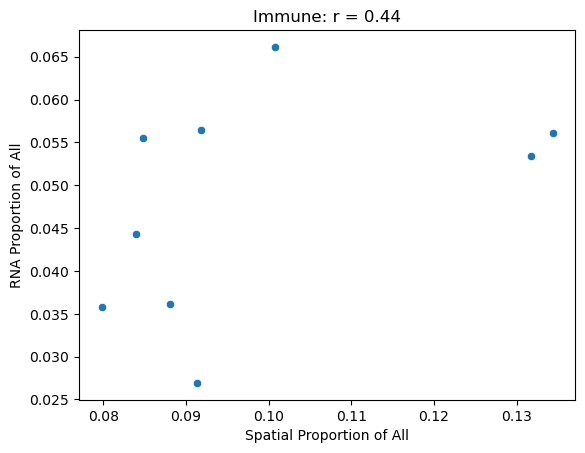

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

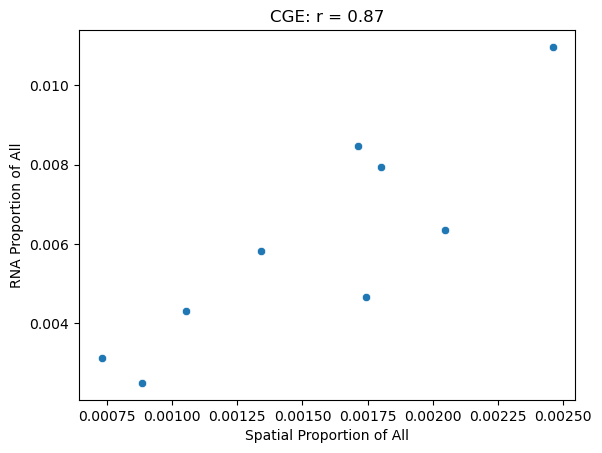

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

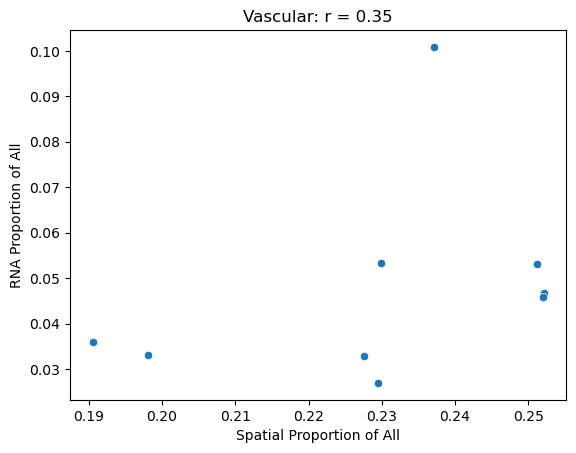

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

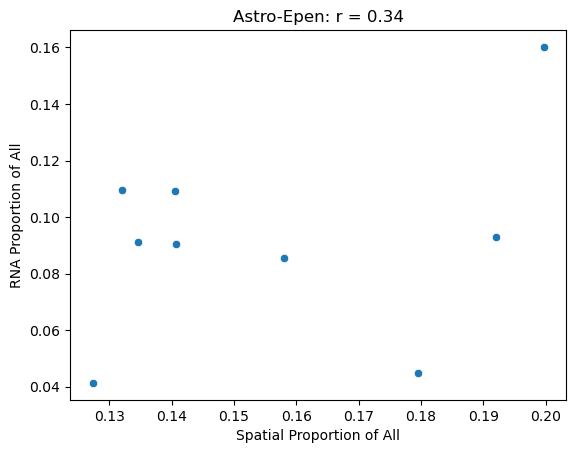

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

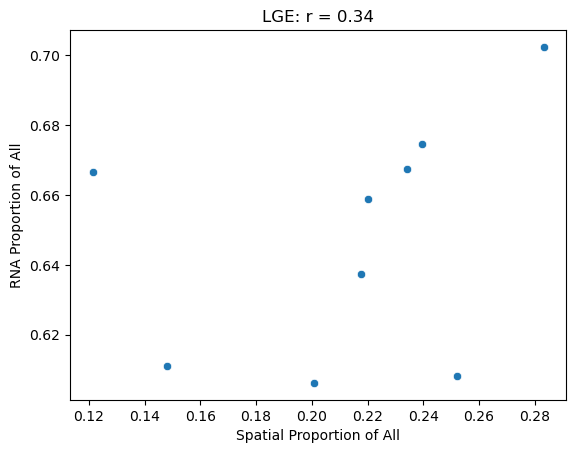

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

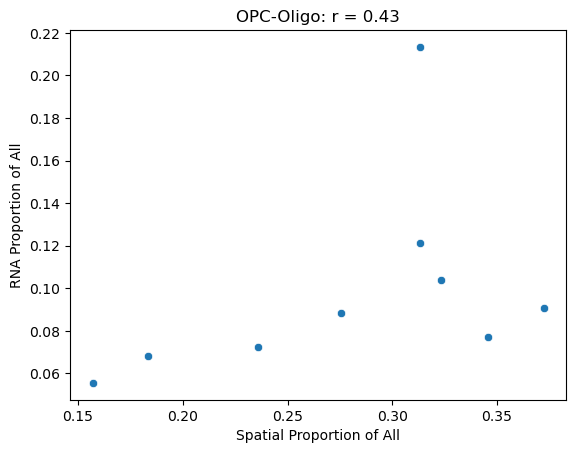

/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
/tmp/ipykernel_28391/2021039828.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

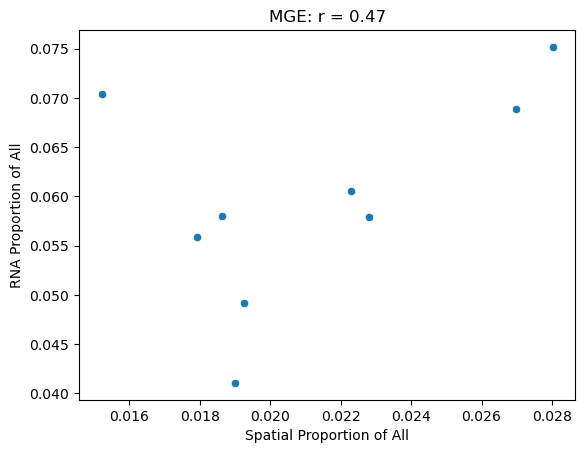

/tmp/ipykernel_28391/4205716372.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return obs.groupby(child)[parent].first().to_dict()
/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

{('STR RSPO2 GABA', 'MGE'), ('Endothelial', 'Vascular'), ('Vip', 'CGE'), ('CN ST18 GABA', 'MGE'), ('Oligodendrocyte', 'OPC-Oligo'), ('STR D1 MSN', 'LGE'), ('Microglia-PVM', 'Immune'), ('STR D2 MSN', 'LGE'), ('CN LAMP5-CXCL14 GABA', 'CGE'), ('Ependymal', 'Astro-Epen'), ('STR Hybrid MSN', 'LGE'), ('OPC', 'OPC-Oligo'), ('Astrocyte', 'Astro-Epen'), ('VLMC', 'Vascular'), ('Sst Chodl', 'MGE')}


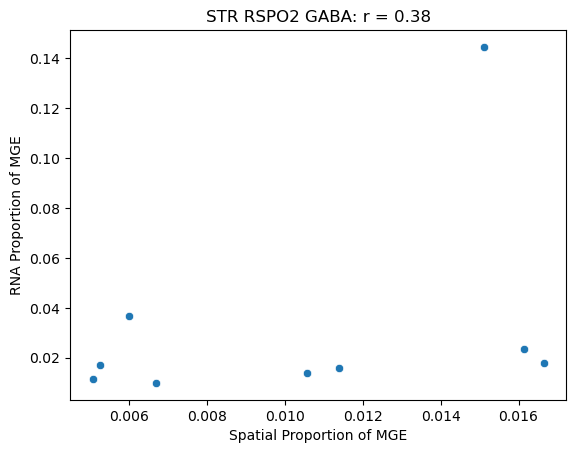

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

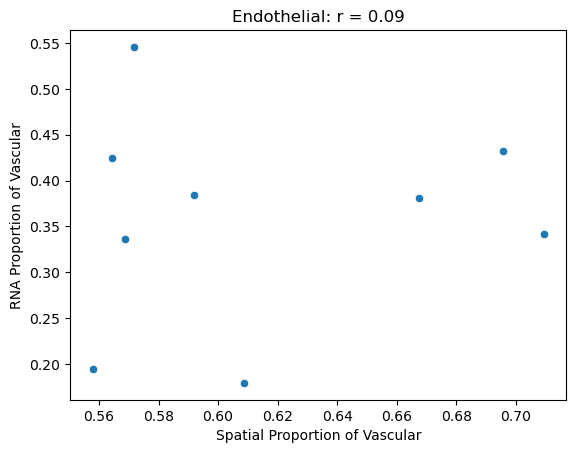

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

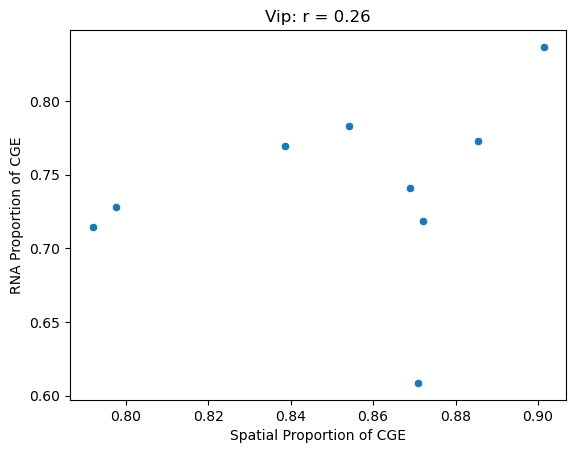

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

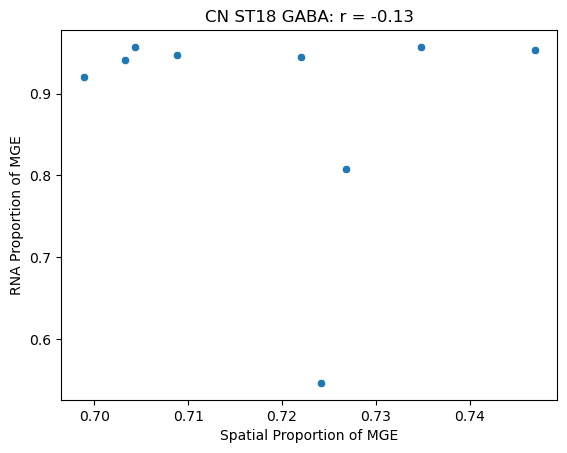

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

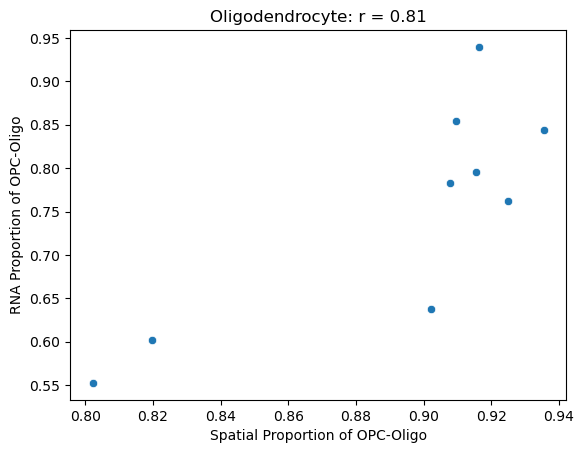

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

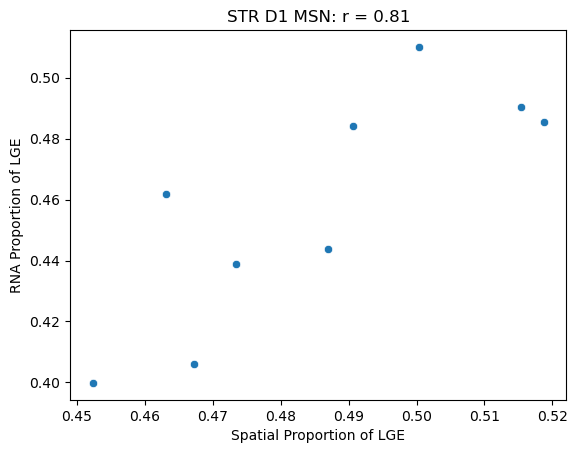

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

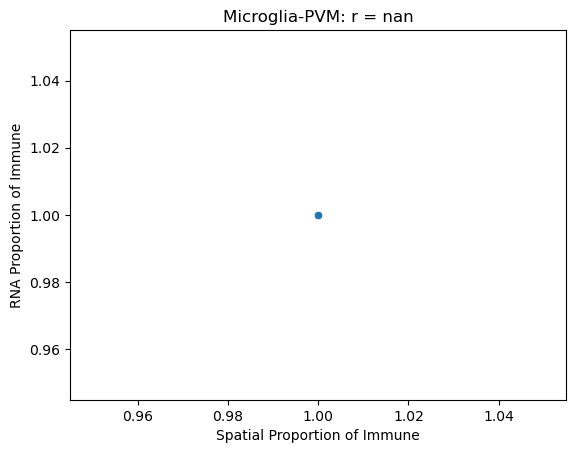

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

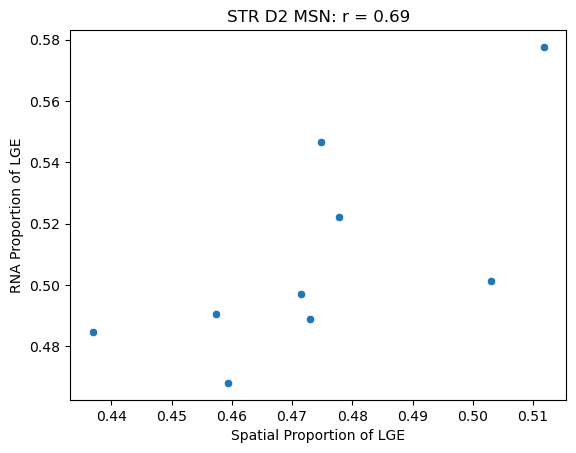

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

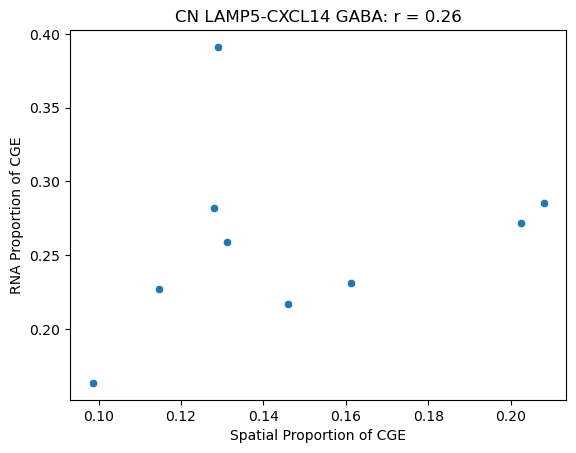

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

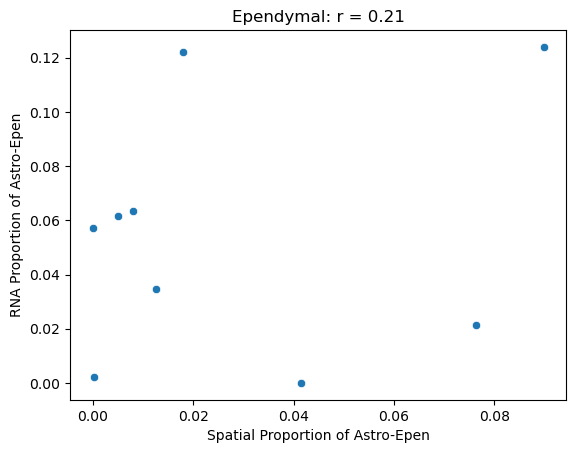

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

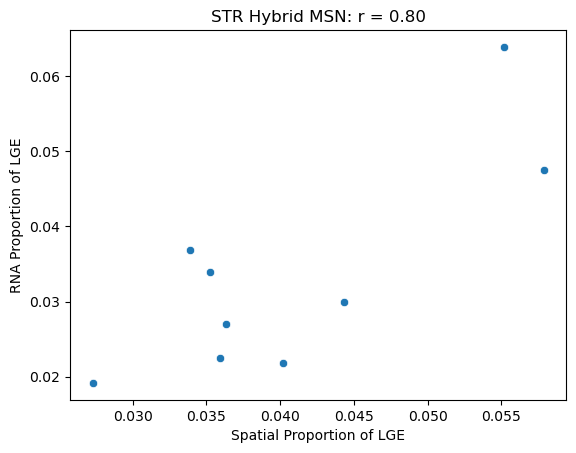

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

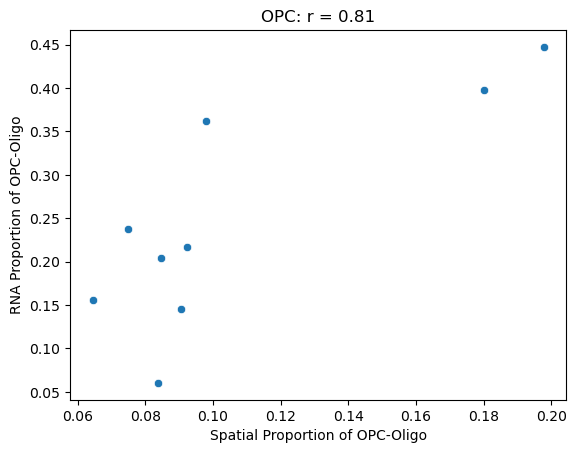

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

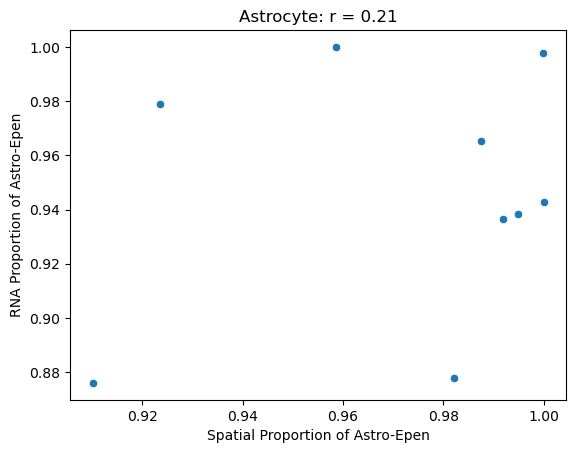

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

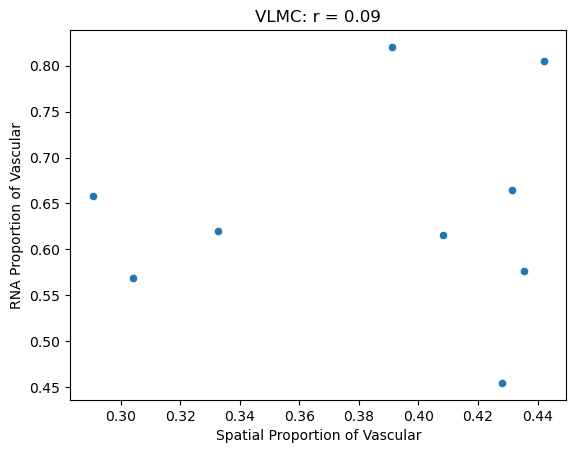

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

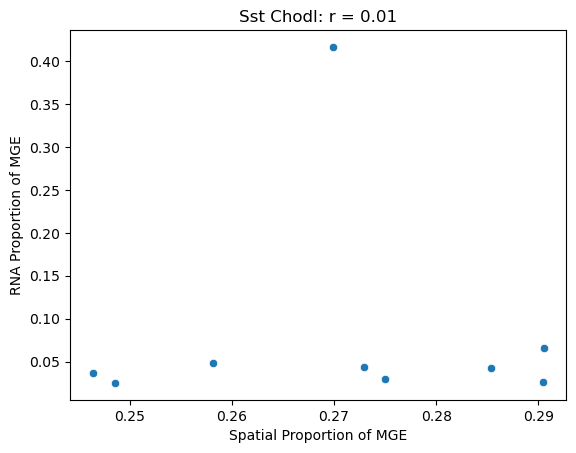

/tmp/ipykernel_28391/4205716372.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return obs.groupby(child)[parent].first().to_dict()
/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

{('Micro-PVM_2_1-SEAAD', 'Microglia-PVM'), ('OPC_2_1-SEAAD', 'OPC'), ('Astro_6-SEAAD', 'Astrocyte'), ('Endo_2', 'Endothelial'), ('Micro-PVM_4-SEAAD', 'Microglia-PVM'), ('Sst Chodl_1', 'Sst Chodl'), ('Micro-PVM_1', 'Microglia-PVM'), ('Micro-PVM_3-SEAAD', 'Microglia-PVM'), ('STR TAC3-PLPP4-LHX8 GABA', 'CN ST18 GABA'), ('Vip_14', 'Vip'), ('OPC_2', 'OPC'), ('Pericyte_2-SEAAD', 'VLMC'), ('Vip_1', 'Vip'), ('Vip_15', 'Vip'), ('SMC-SEAAD', 'VLMC'), ('STR FS PTHLH-PVALB GABA', 'CN ST18 GABA'), ('Oligo_4', 'Oligodendrocyte'), ('Vip_11', 'Vip'), ('Vip_9', 'Vip'), ('OPC_2_2-SEAAD', 'OPC'), ('Oligo_2_1-SEAAD', 'Oligodendrocyte'), ('Vip_16', 'Vip'), ('STR VIP GABA', 'Vip'), ('STRd D1 Matrix MSN', 'STR D1 MSN'), ('STRv D1 NUDAP MSN', 'STR Hybrid MSN'), ('STRv D2 MSN', 'STR D2 MSN'), ('BG LAMP5-CXCL14 GABA', 'CN LAMP5-CXCL14 GABA'), ('STR PVALB-RSPO2 GABA', 'STR RSPO2 GABA'), ('Vip_23', 'Vip'), ('STRd D1D2 Hybrid MSN', 'STR Hybrid MSN'), ('STRd D2 Striosome MSN', 'STR D2 MSN'), ('Astro_5', 'Astrocyte'

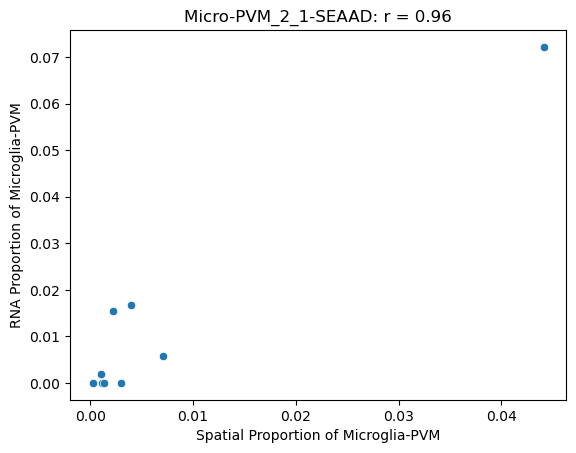

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

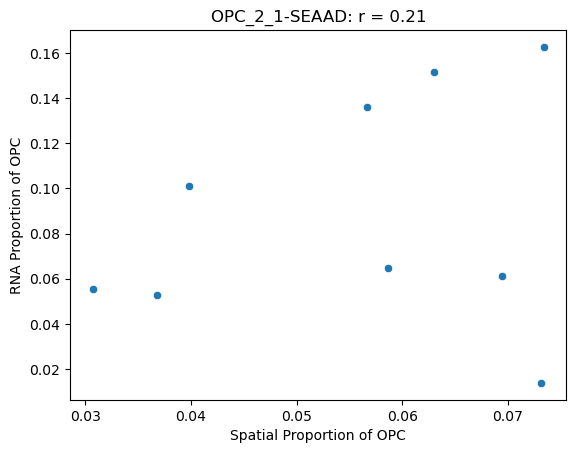

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

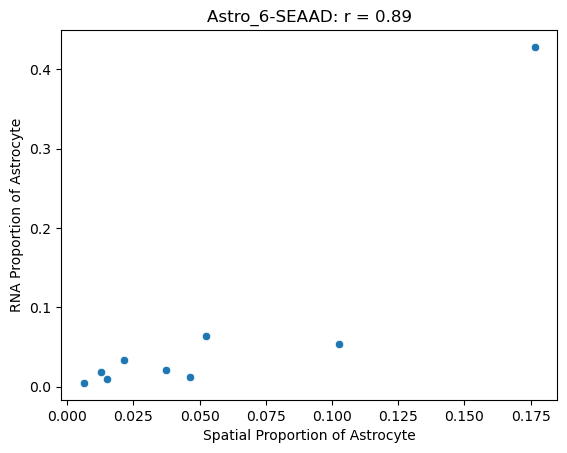

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

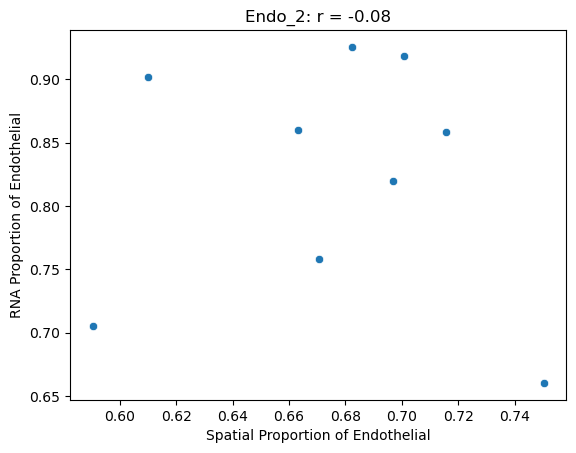

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

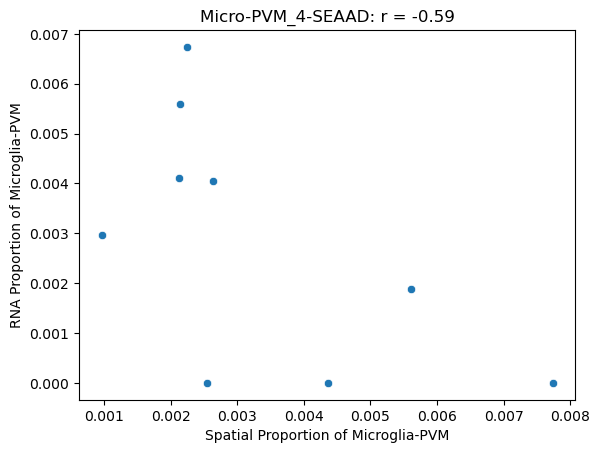

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

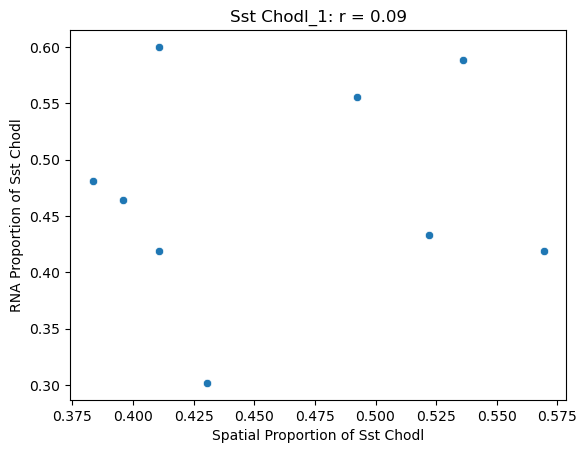

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

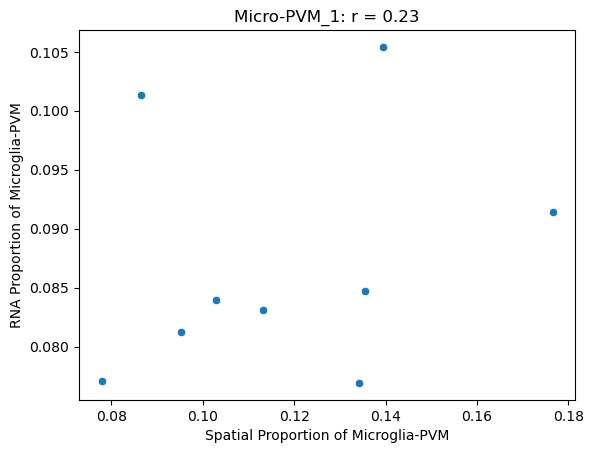

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

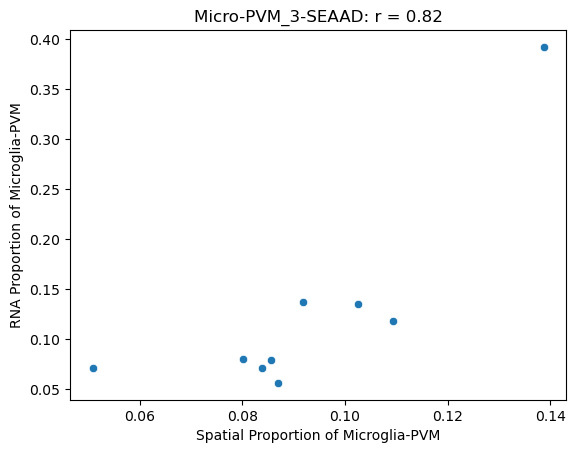

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

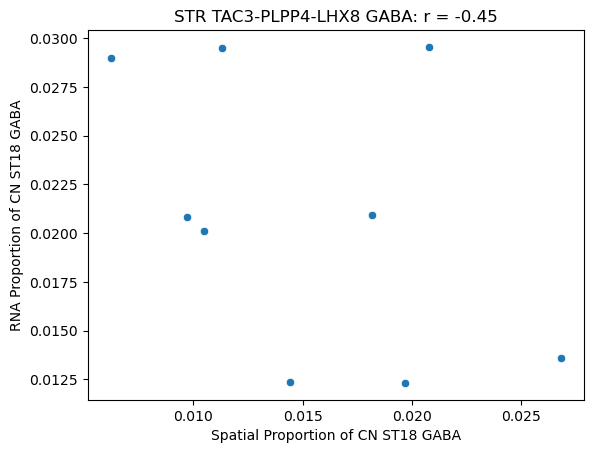

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

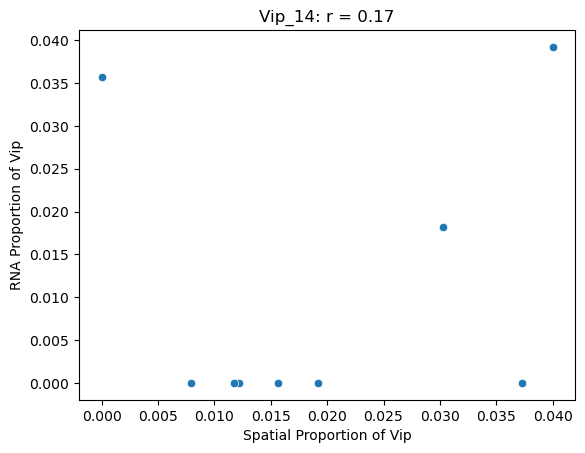

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

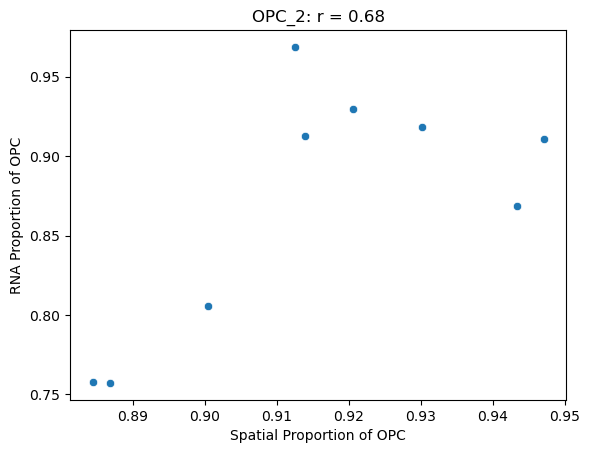

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

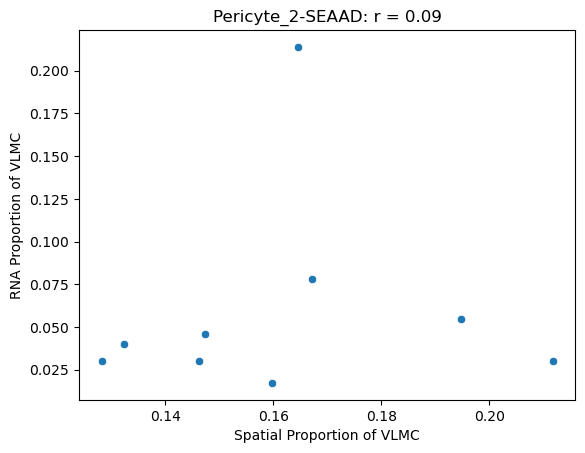

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

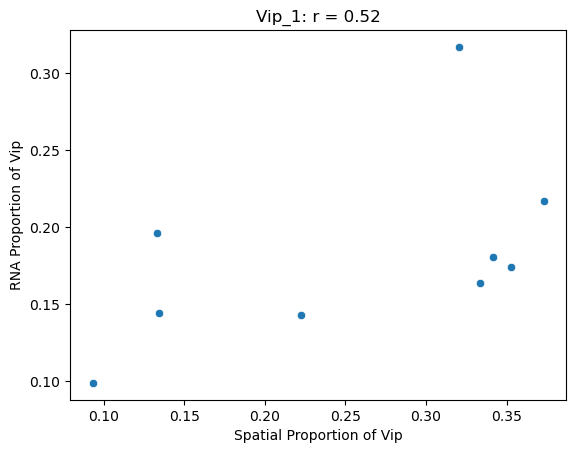

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

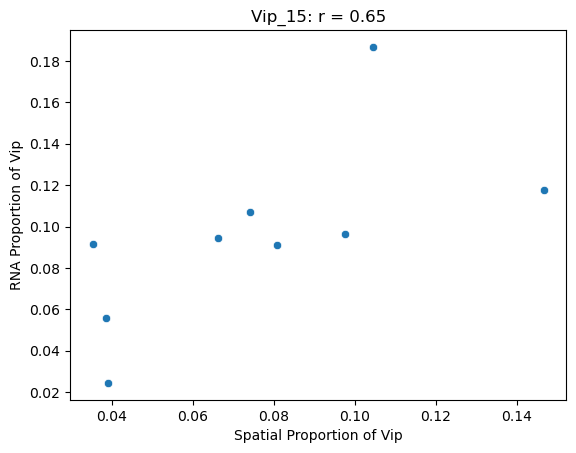

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

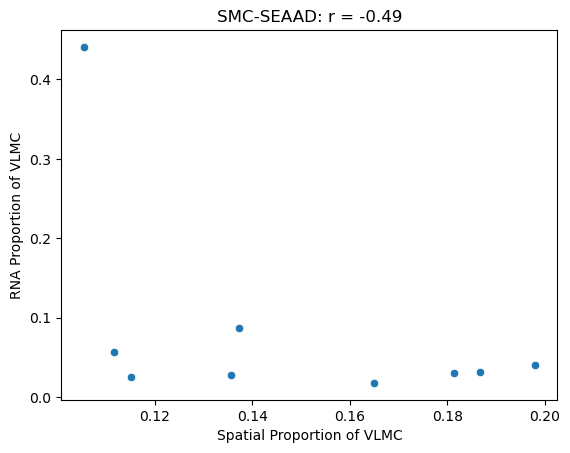

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

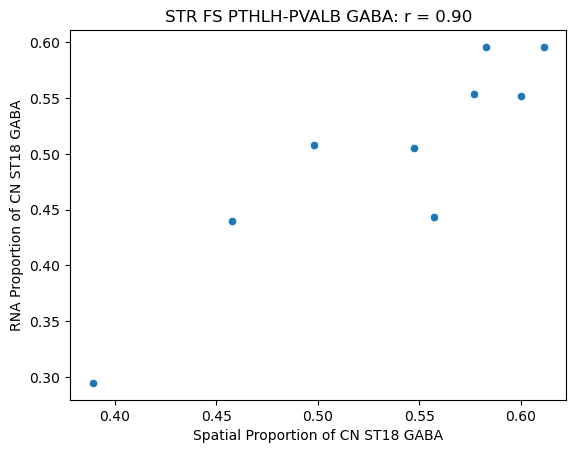

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

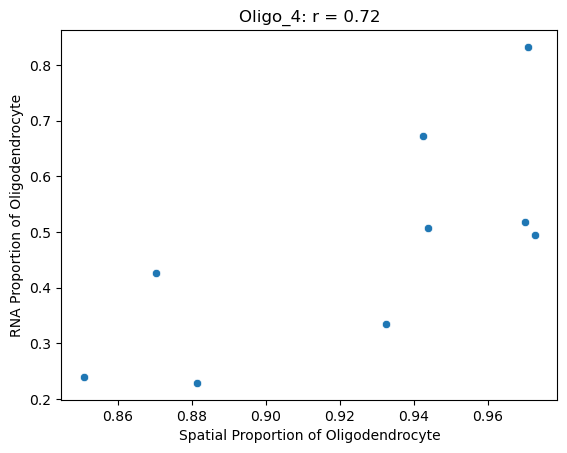

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

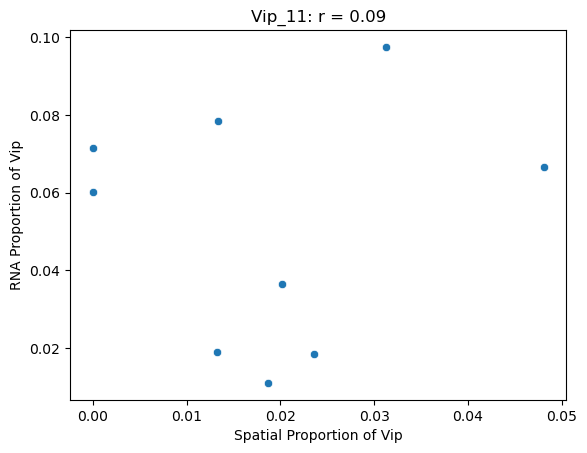

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

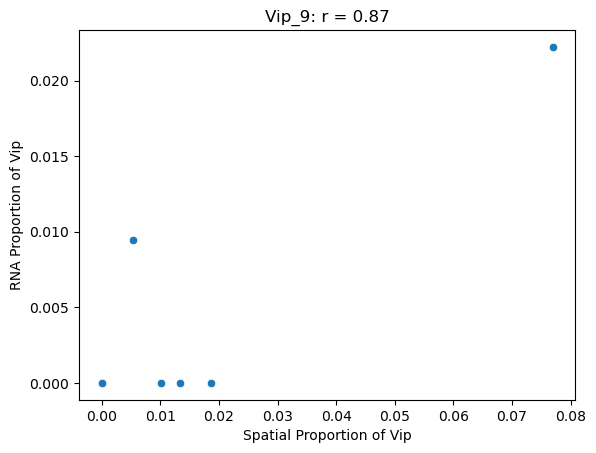

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

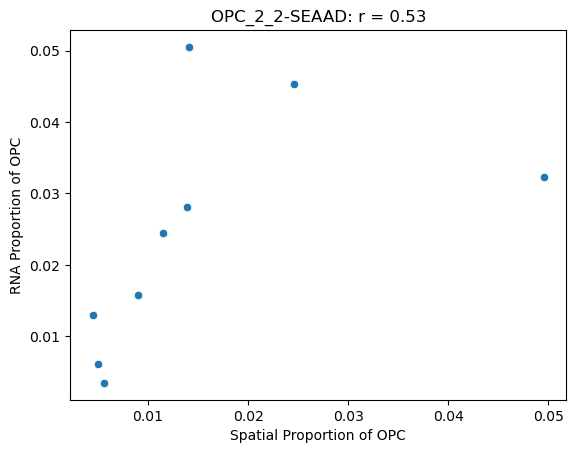

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

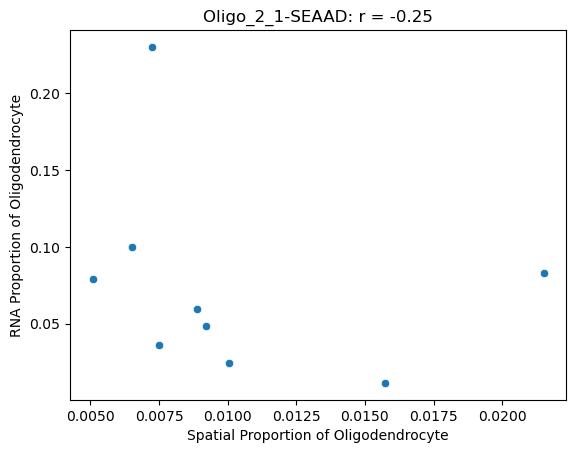

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

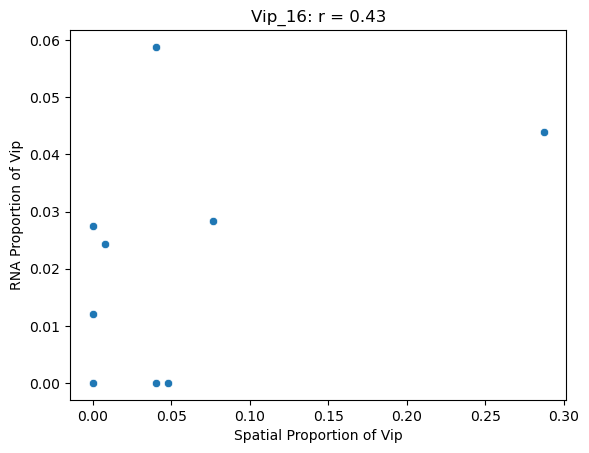

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

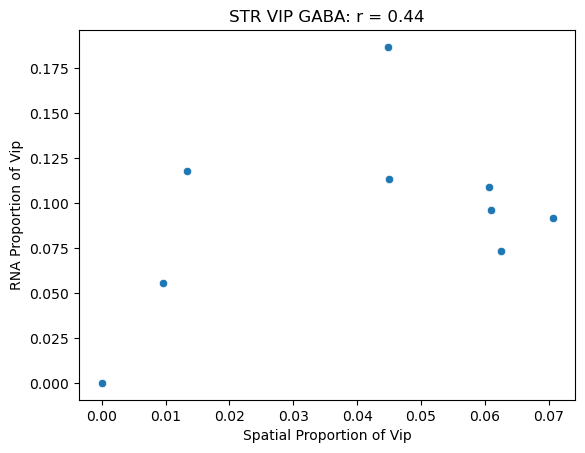

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

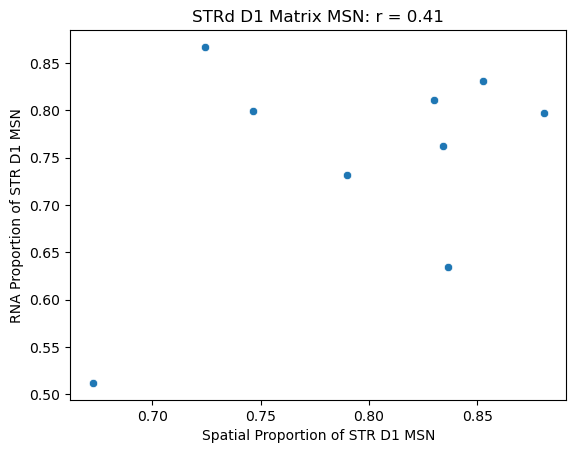

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

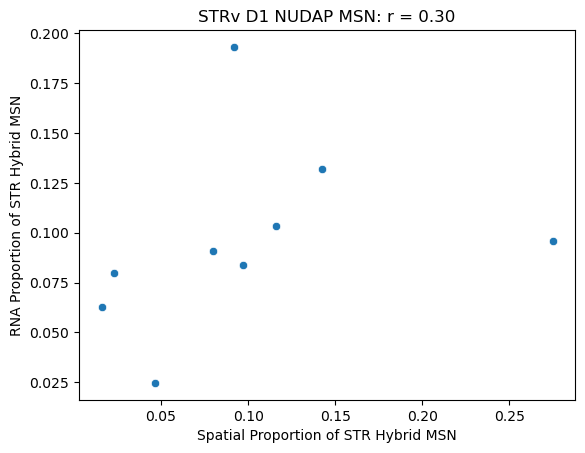

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

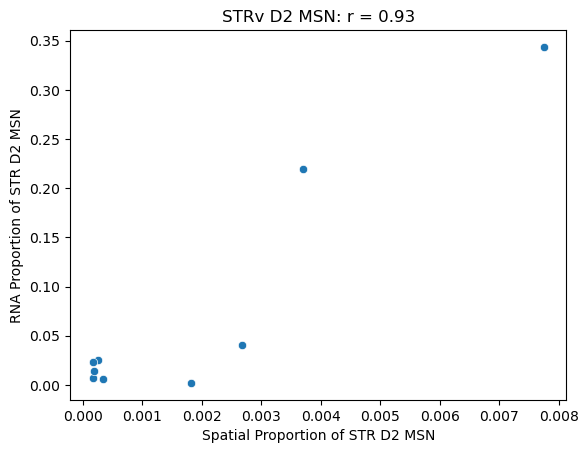

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

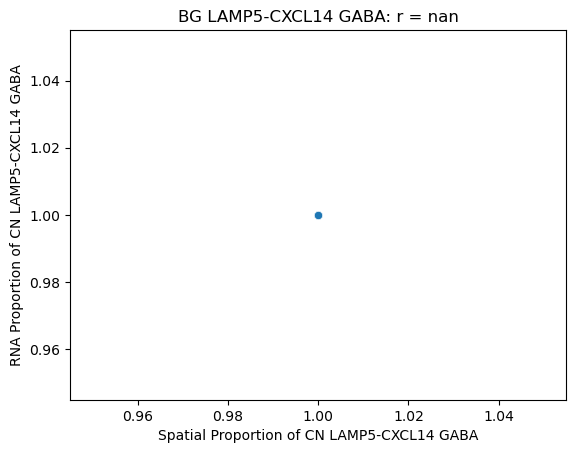

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

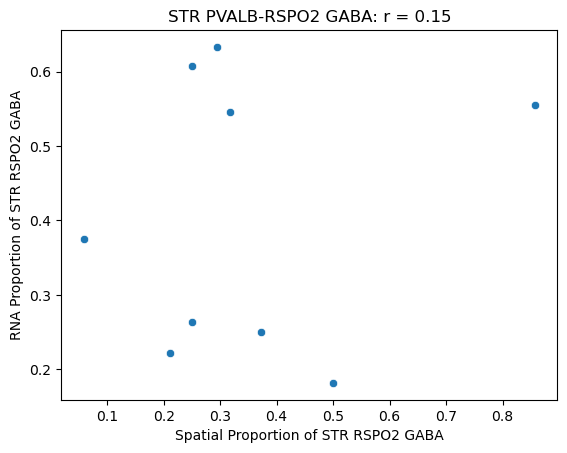

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

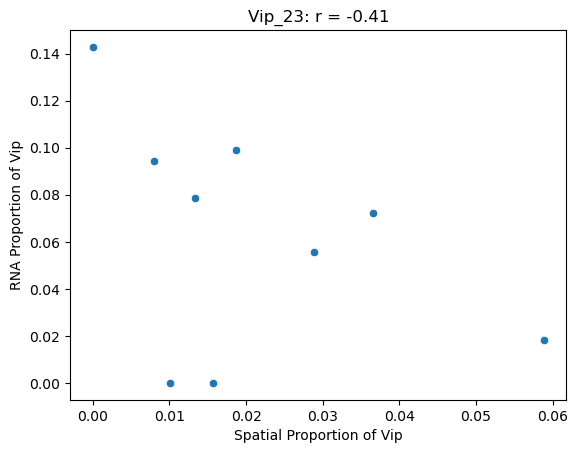

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

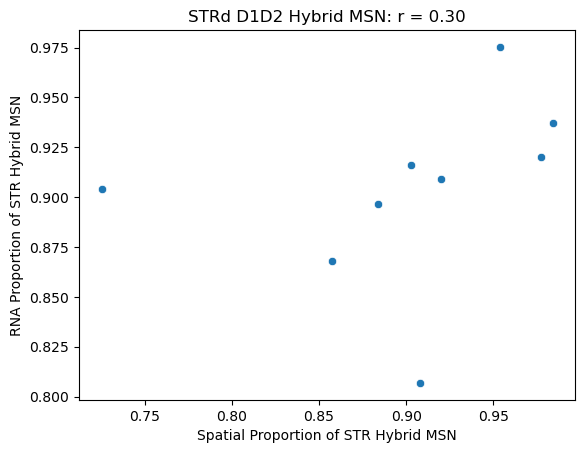

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

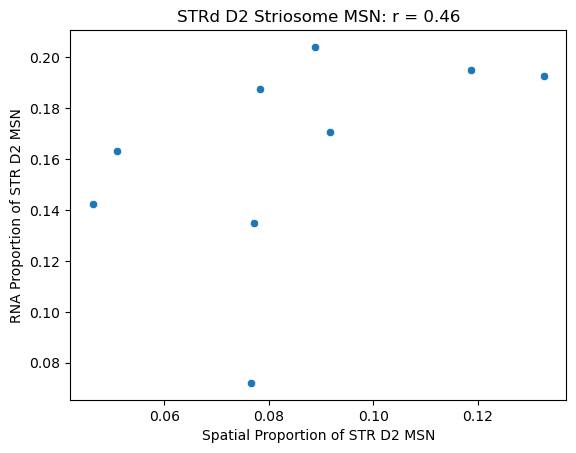

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

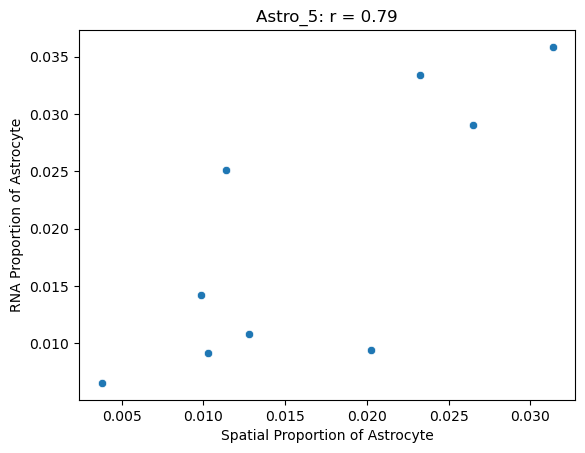

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

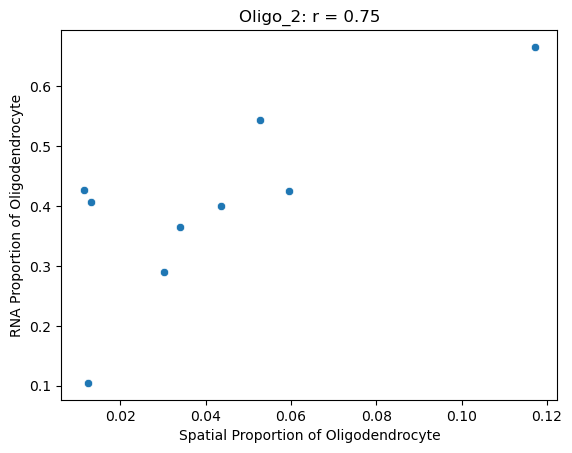

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

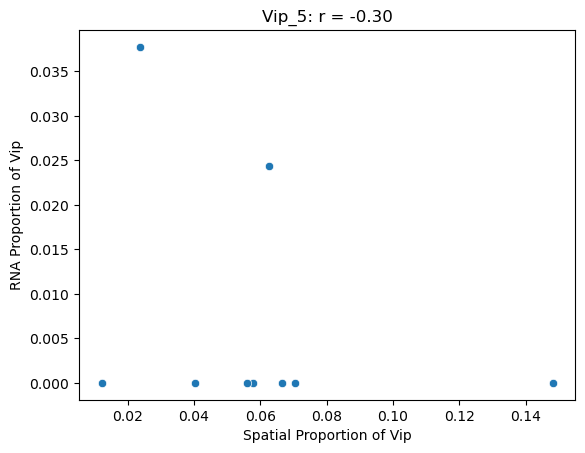

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

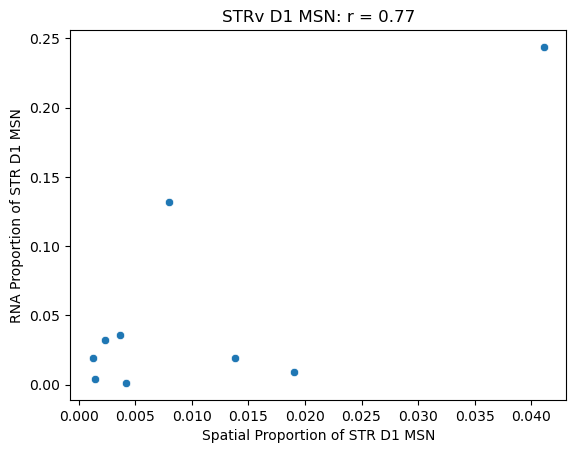

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

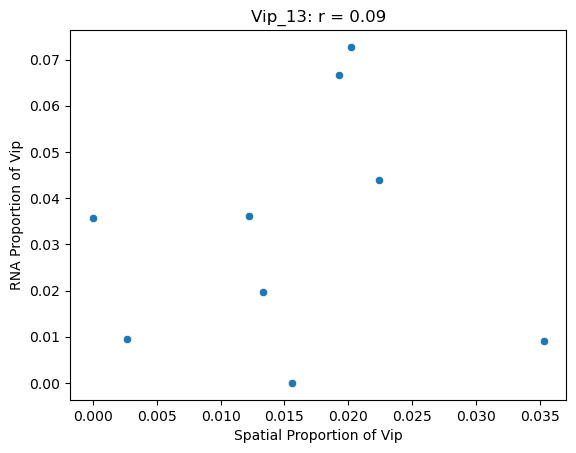

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

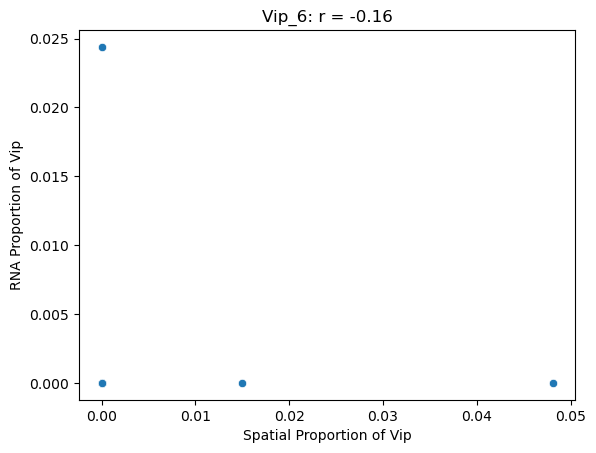

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

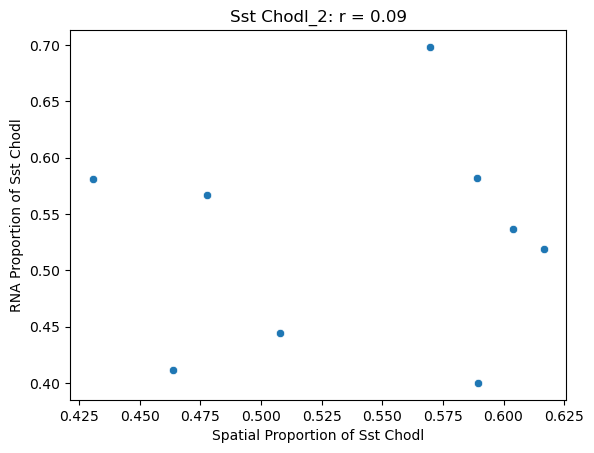

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

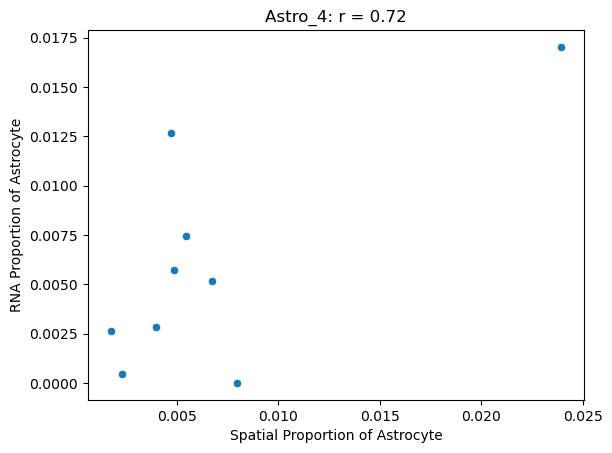

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

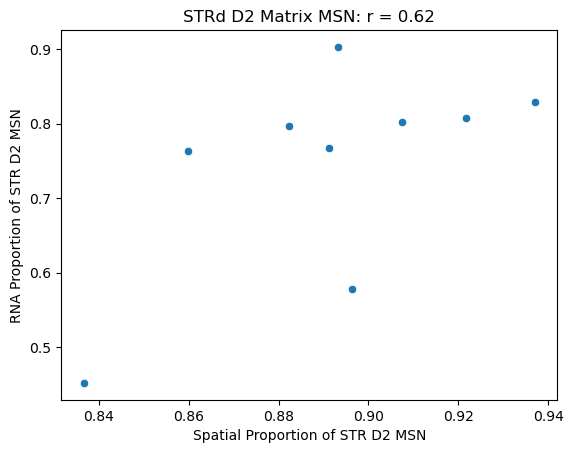

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

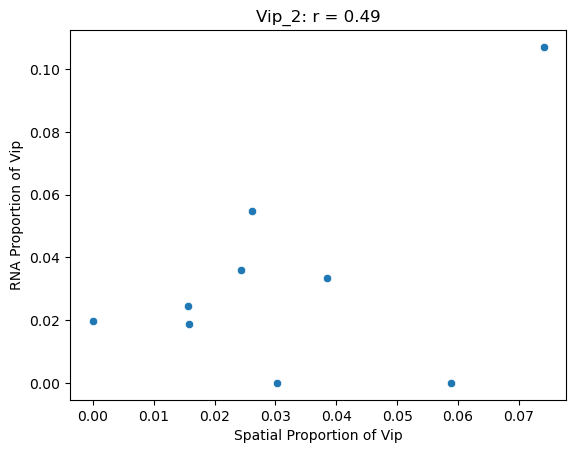

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

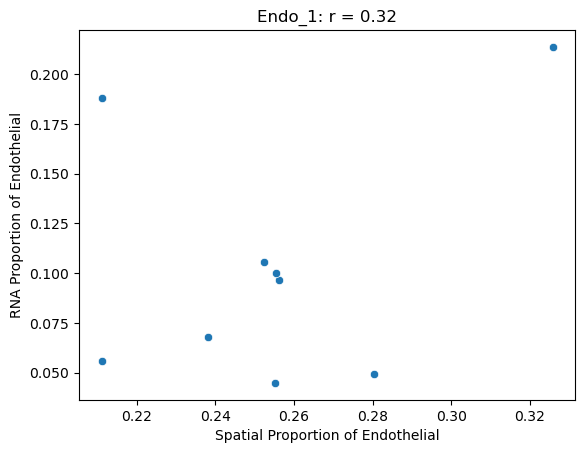

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

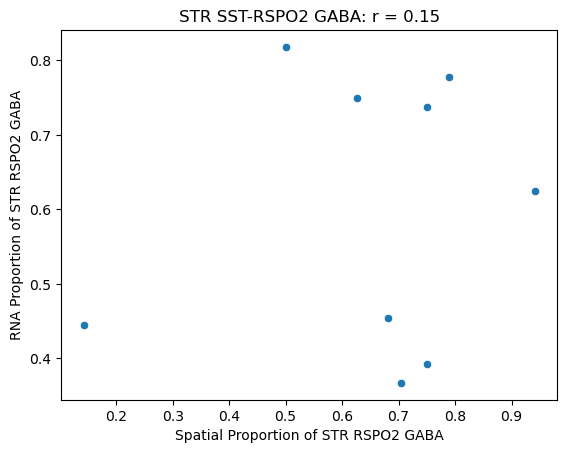

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

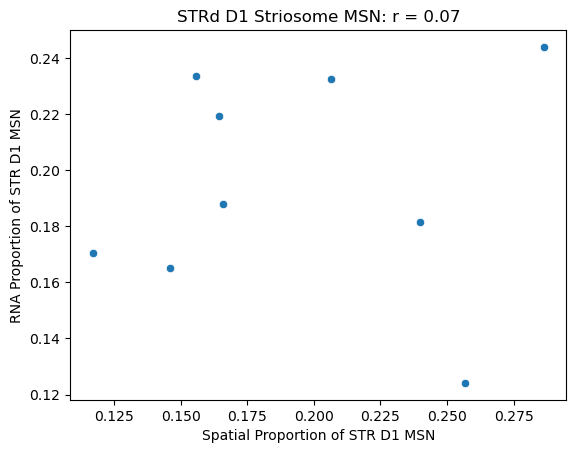

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

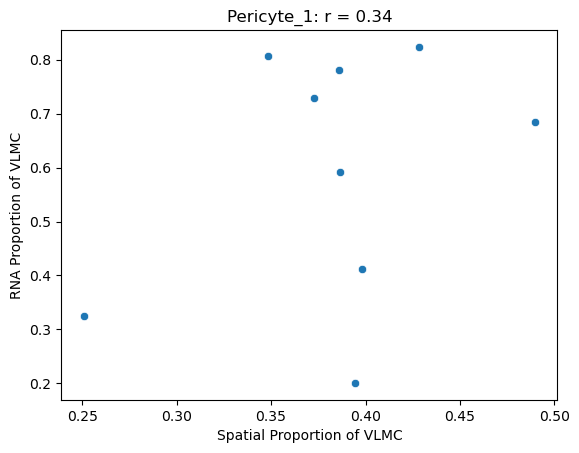

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

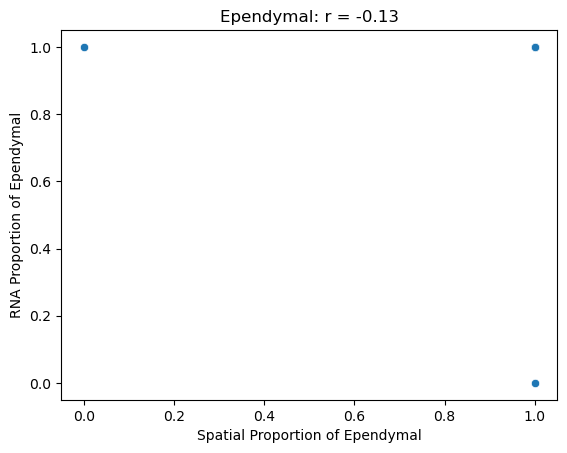

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

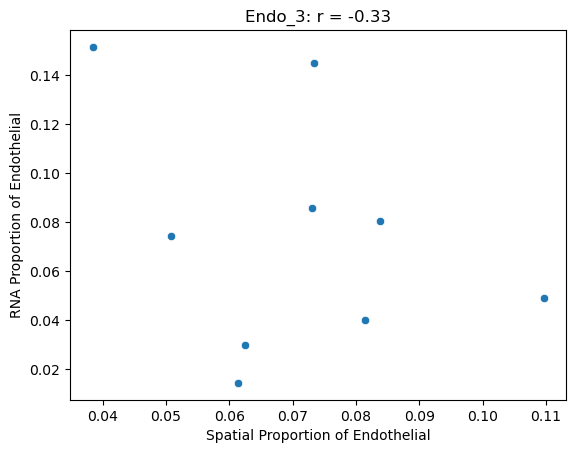

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

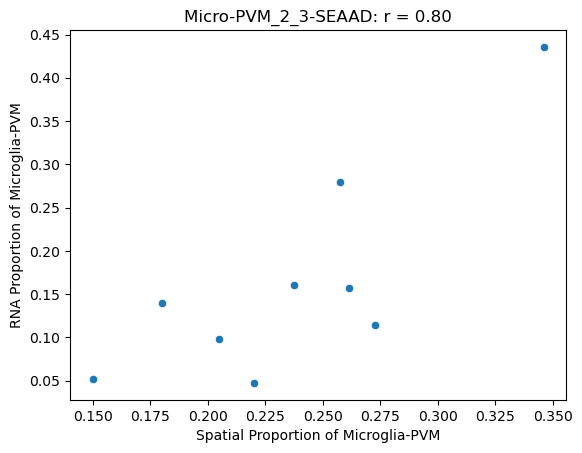

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

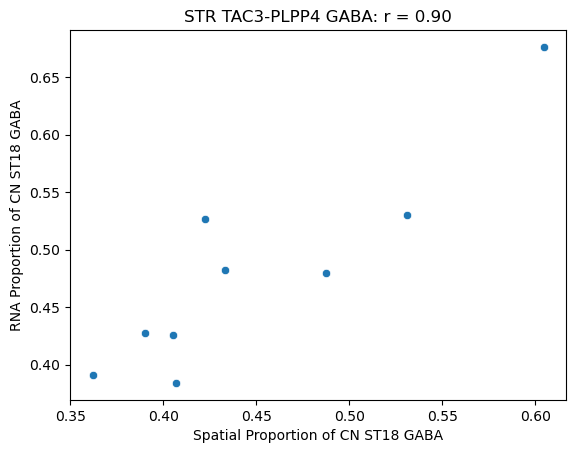

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

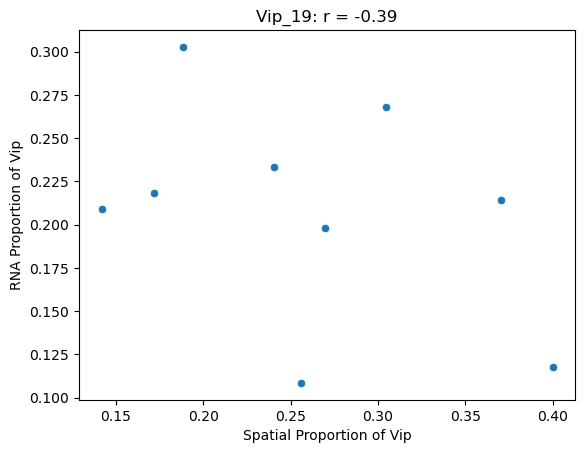

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

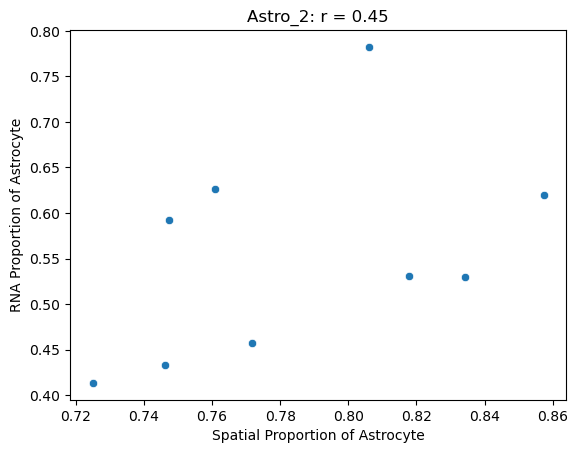

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

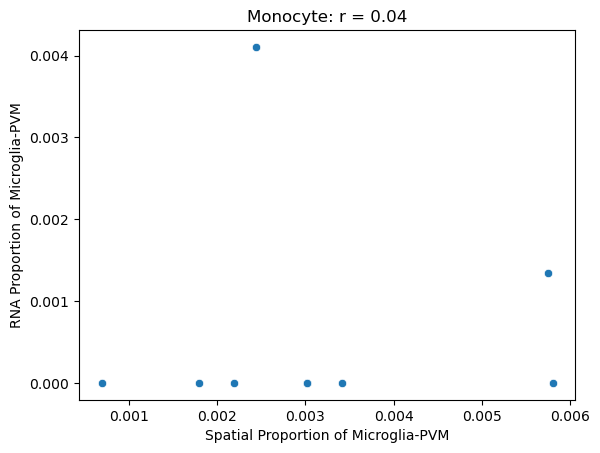

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

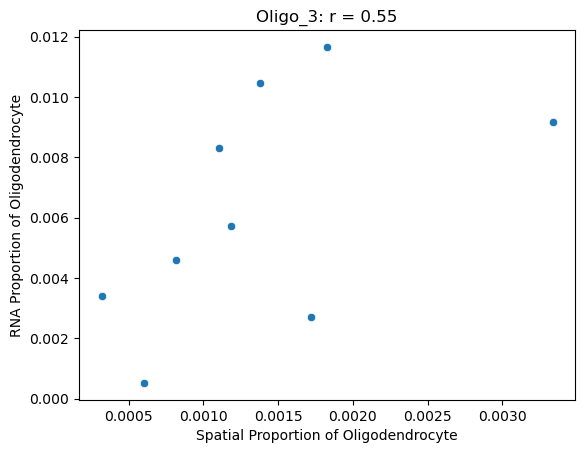

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

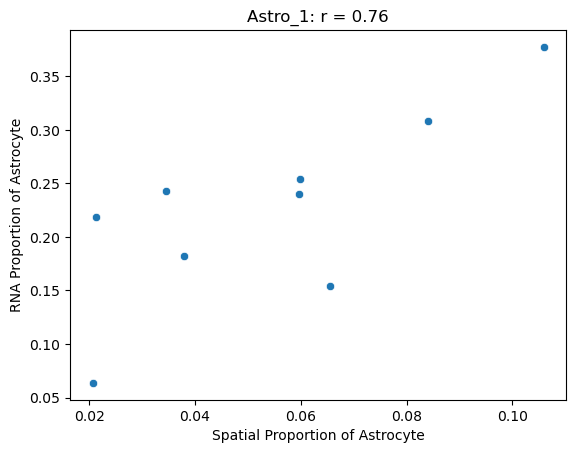

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

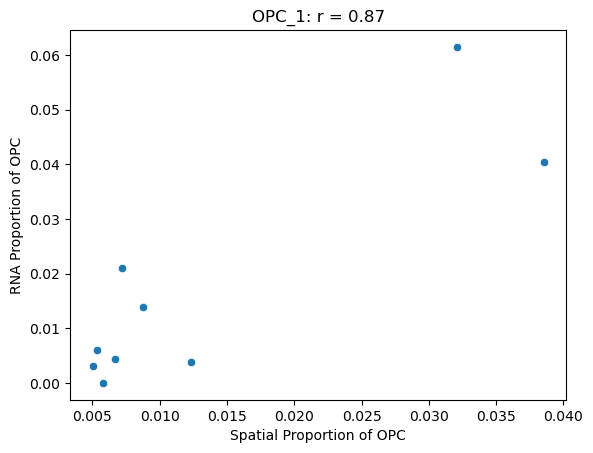

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

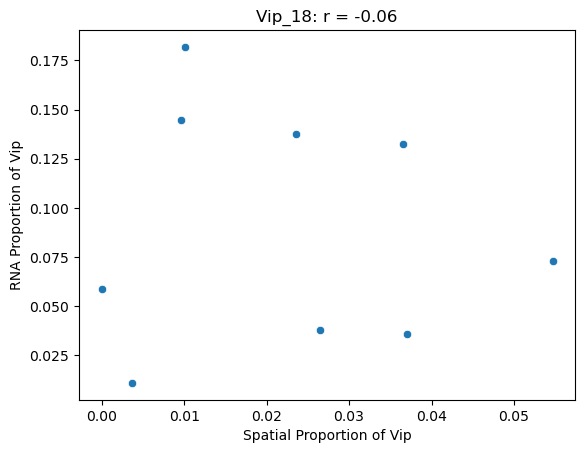

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

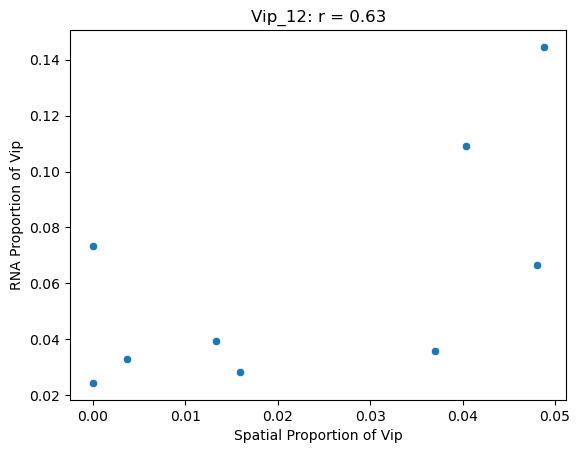

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

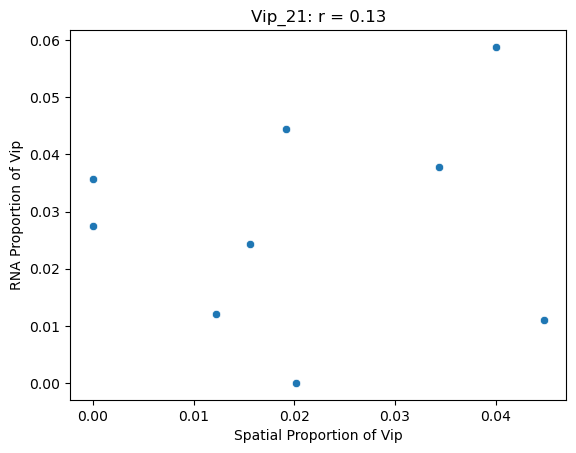

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

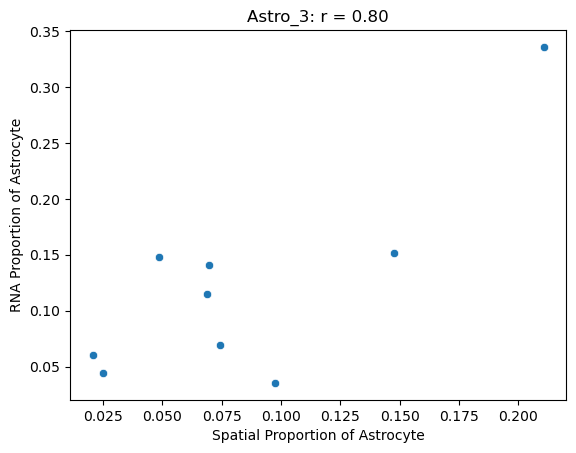

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

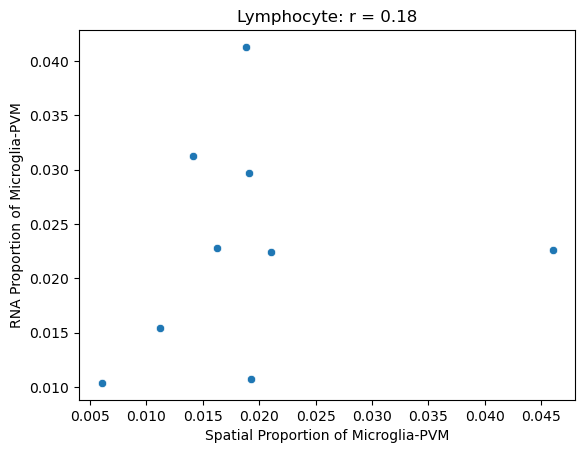

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

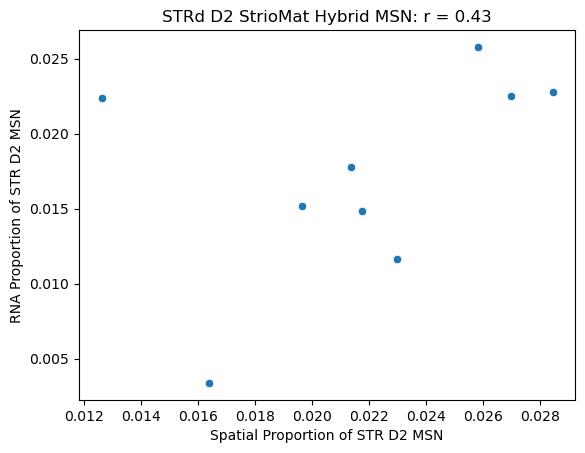

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

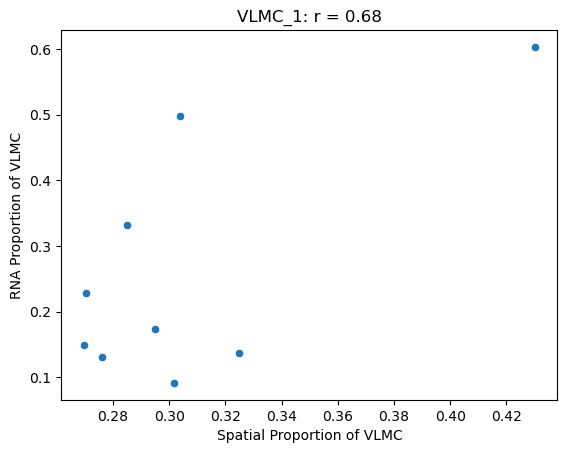

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

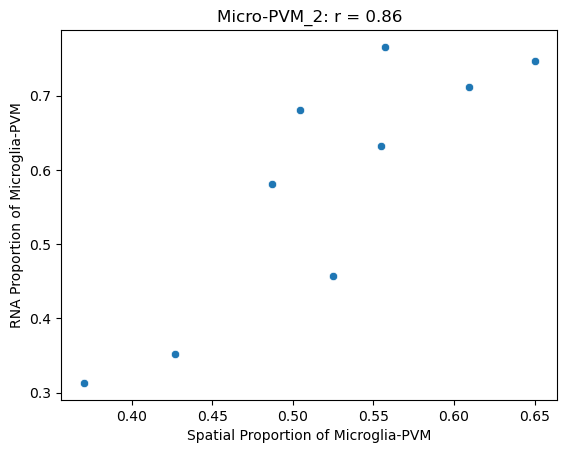

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

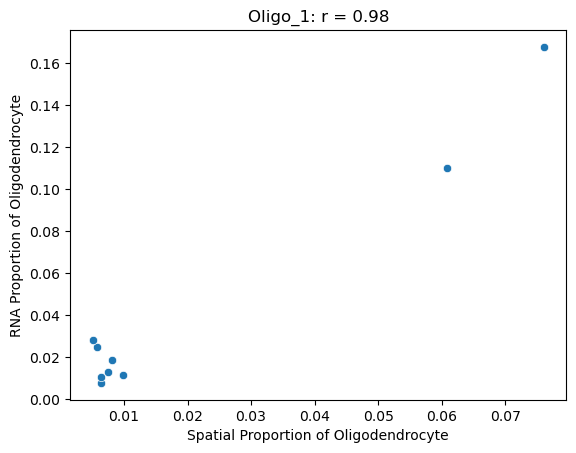

/tmp/ipykernel_28391/2021039828.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
/tmp/ipykernel_28391/2021039828.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

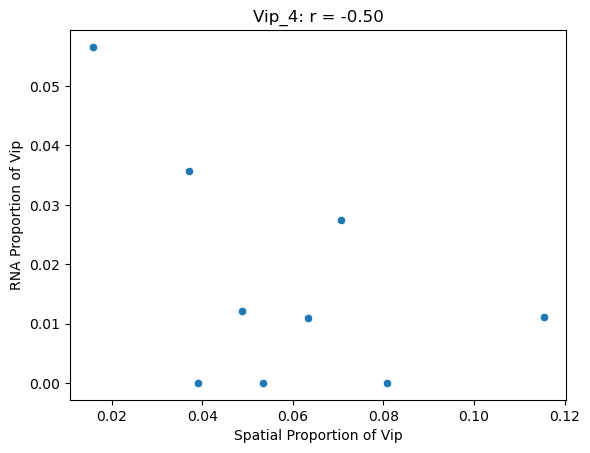

In [61]:
for child_col, parent_col in {"Neighborhood":None, "Subclass":"Neighborhood", "Supertype":"Subclass"}.items():
    spatial_conv_dict = get_conv_dict(spatial_obs, child_col, parent_col)
    rna_conv_dict = get_conv_dict(rna_obs, child_col, parent_col)
    conv_items = spatial_conv_dict.items() & rna_conv_dict.items()
    # x = spatial_obs.groupby(["Donor ID", 'barcode'])[child_col].value_counts(normalize = True).reset_index().groupby(["Donor ID", child_col])['proportion'].mean()
    # x_err = spatial_obs.groupby(["Donor ID", 'barcode'])[child_col].value_counts(normalize = True).reset_index().groupby(["Donor ID", child_col])['proportion'].std()
    # y = rna_obs_subset.groupby(["Donor ID", "library_prep"])[child_col].value_counts(normalize = True).reset_index().groupby(["Donor ID", child_col])["proportion"].mean()
    # y_err = rna_obs_subset.groupby(["Donor ID", "library_prep"])[child_col].value_counts(normalize = True).reset_index().groupby(["Donor ID", child_col])["proportion"].std()
    print(conv_items)
    for child_cluster, parent_cluster in conv_items:
        mask = x_cluster.notna() & y_cluster.notna()
        if parent_cluster == "All":
            spatial_obs_subset = spatial_obs.loc[(spatial_obs['Donor ID'].isin(donors))]
            rna_obs_subset = rna_obs.loc[(rna_obs['Donor ID'].isin(donors))]
        else:
            spatial_obs_subset = spatial_obs[(spatial_obs[parent_col] == parent_cluster) & (spatial_obs['Donor ID'].isin(donors))]
            rna_obs_subset = rna_obs[(rna_obs[parent_col] == parent_cluster ) & (rna_obs['Donor ID'].isin(donors))]
        spatial_obs_subset["Donor ID"] = spatial_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
        rna_obs_subset['Donor ID'] = rna_obs_subset['Donor ID'].astype("category").cat.set_categories(donors)
        x = spatial_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
        y = rna_obs_subset.groupby("Donor ID")[child_col].value_counts(normalize = True)
        x_cluster = x.xs(child_cluster, level = child_col)
        y_cluster =  y.xs(child_cluster, level = child_col)
        ax = sns.scatterplot(x = x_cluster[mask], y = y_cluster[mask])# hue =hue, palette='YlGnBu') 
        # plt.errorbar(x=x.xs(child_cluster, level = child_col), y=y.xs(child_cluster, level = child_col), xerr = x_err.xs(child_cluster, level = child_col), yerr=y_err.xs(child_cluster, level = child_col), fmt='none', ecolor='black', capsize=4)
        ax.set_xlabel(f'Spatial Proportion of {parent_cluster}')
        # ax.set_xscale('log')
        ax.set_ylabel(f'RNA Proportion of {parent_cluster}')
        # ax.set_yscale('log')
        ax.set_title(f'{child_cluster}: r = {pearsonr(x_cluster[mask], y_cluster[mask])[0]:.2f}')
        # ax.get_legend().remove()
        # ax.figure.colorbar(sm, ax=ax)
        plt.show()

In [89]:
spaital_adata

NameError: name 'spaital_adata' is not defined

In [90]:
from pathlib import Path
import geopandas as gpd
import anndata as ad
import pandas as pd
from shapely import convex_hull, GeometryCollection
import zarr
from anndata.io import read_elem
from tqdm import tqdm

def cell_convex_hull_area(
    zarr_dir: Path | str,
    shape_element: str = "cell_boundaries",
) -> float:
    """Rough area of a biological section from its cell boundaries.

    Uses the convex hull of all cell geometries as a fast approximation
    (overestimates true section area by ~10-20% for concave sections).

    Note: coordinates are read straight from the GeoParquet, so the area
    is in the shapes' intrinsic units squared (transforms stored in the
    zarr metadata are not applied).
    """
    zarr_dir = Path(zarr_dir)
    parquet = zarr_dir / "shapes" / shape_element / "shapes.parquet"
    cell_gdf = gpd.read_parquet(parquet)
    return convex_hull(GeometryCollection(cell_gdf.geometry.tolist())).area

def read_zarr_obs(zarr_dir: Path | str, table_element: str = "mapped_table") -> pd.DataFrame:
    """Read only the obs DataFrame from a SpatialData table, skipping X/layers/obsm."""
    zarr_dir = Path(zarr_dir)
    g = zarr.open(str(zarr_dir / "tables" / table_element), mode="r")
    return read_elem(g["obs"])

def get_n_cells(obs:pd.DataFrame, cluster_labels: str, replicate_col: str | None) -> pd.DataFrame:
    if replicate_col is None:
        return obs[cluster_labels].value_counts()
    else:
        return obs.groupby(replicate_col)[cluster_labels].value_counts()


def get_cell_density(
    zarr_dir: Path | str, 
    shape_element:str = "cell_boundaries", 
    table_element: str = "mapped_table",
    replicate_col: str = None,
    cluster_labels: str = "CDM_Subclass_name",
    pixel_scale: float = 0.2125
    ):
    """Read in spatialdata zarr and return cellular density"""
    section_area = cell_convex_hull_area(zarr_dir, shape_element)
    section_obs = read_zarr_obs(zarr_dir, table_element)
    section_n_cells = get_n_cells(section_obs, cluster_labels, replicate_col)
    return section_n_cells / (section_area * pixel_scale**2)

def get_density_dataframe(
    dir_zarr_dir: Path | str,
    **kwargs
):
    series_dict = {}
    dir_zarr_dir = Path(dir_zarr_dir)
    zarr_dirs = list(dir_zarr_dir.glob("*.zarr"))
    for zarr_dir in tqdm(zarr_dirs):
        barcode = zarr_dir.stem.split("_")[0]
        series_dict[barcode] = get_cell_density(zarr_dir, **kwargs)
    return pd.DataFrame(series_dict)

In [94]:
cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()

/tmp/ipykernel_28391/2692713578.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()


In [109]:
spatial_cps_obs = spatial_obs[['Donor ID', 'barcode']].merge(cps_obs, on = "Donor ID")

In [ ]:
density_df = get_density_dataframe("/root/capsule/data/spatialdata")


100%|██████████| 28/28 [05:15<00:00, 11.27s/it]


In [105]:
long_density_df = density_df.stack().reset_index().rename(columns = {"level_1":"barcode", 0:"density"})

In [111]:
long_density_df = long_density_df.merge(spatial_cps_obs, on = "barcode")

In [113]:
long_density_df['Pathology Level'] = (long_density_df['CPS'] > 0.9).replace({True:"High", False:"Low"})

In [150]:
long_density_df_part = long_density_df[['CDM_Subclass_name', 'density', 'Pathology Level']]

In [151]:
long_density_part = long_density_df_part.drop_duplicates()

In [152]:
long_density_part['Pathology Level'] = long_density_part["Pathology Level"].astype("category").cat.reorder_categories(['Low', 'High'])

/tmp/ipykernel_28391/4023097349.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_density_part['Pathology Level'] = long_density_part["Pathology Level"].astype("category").cat.reorder_categories(['Low', 'High'])


/opt/conda/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the swarmplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


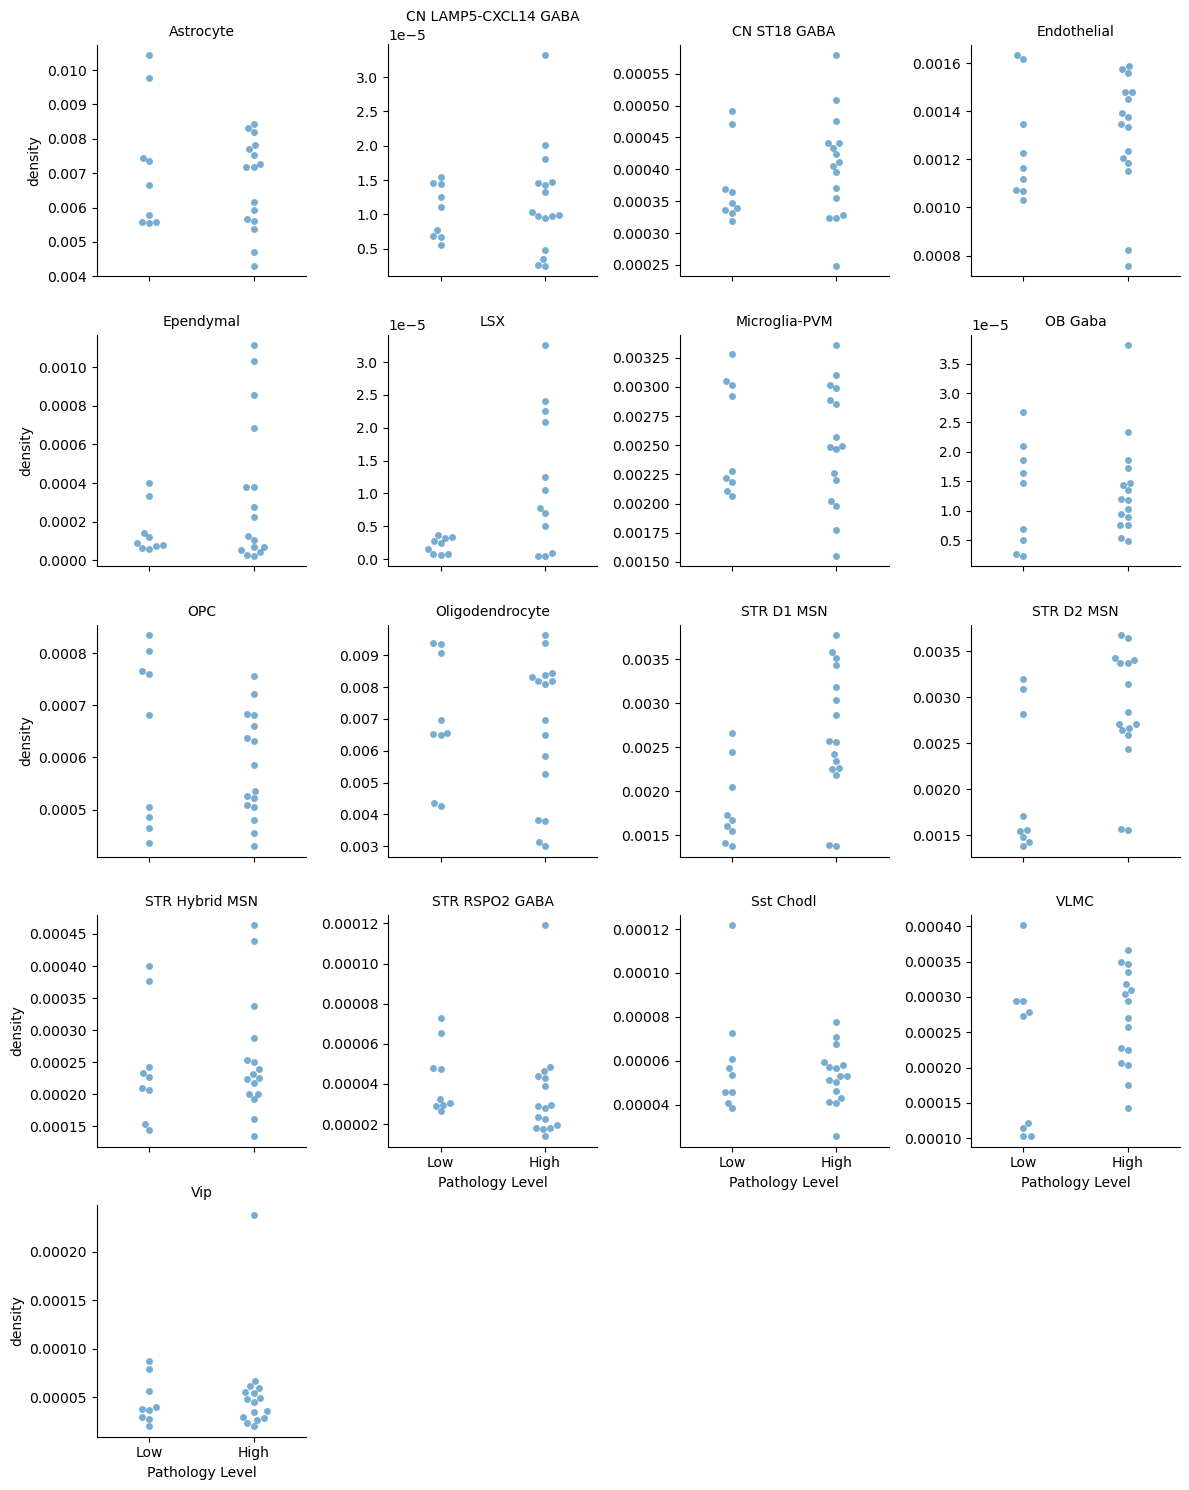

In [153]:
g = sns.FacetGrid(long_density_part, col='CDM_Subclass_name', col_wrap=4, height=3, sharey=False)
g.map(sns.swarmplot, 'Pathology Level', 'density', alpha=0.6)
g.set_titles("{col_name}")

In [121]:
density_df = (
    (
    spatial_obs.groupby(['Donor ID', "barcode"])["Supertype"].value_counts() / 
    denominators
    ).unstack("Supertype")
)

/tmp/ipykernel_28391/2117772015.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby(['Donor ID', "barcode"])["Supertype"].value_counts() /


In [122]:
spatial_obs.groupby("Donor ID")

/tmp/ipykernel_28391/529213748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby("Donor ID")


In [123]:
cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()

/tmp/ipykernel_28391/2692713578.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()


In [124]:
density_df.columns

CategoricalIndex(['Astro_1', 'Astro_2', 'Astro_3', 'Astro_4', 'Astro_5',
                  'Astro_6-SEAAD', 'BG LAMP5-CXCL14 GABA', 'Endo_1', 'Endo_2',
                  'Endo_3', 'Ependymal', 'Lymphocyte', 'Micro-PVM_1',
                  'Micro-PVM_2', 'Micro-PVM_2_1-SEAAD', 'Micro-PVM_2_3-SEAAD',
                  'Micro-PVM_3-SEAAD', 'Micro-PVM_4-SEAAD', 'Monocyte',
                  'OPC_1', 'OPC_2', 'OPC_2_1-SEAAD', 'OPC_2_2-SEAAD',
                  'Oligo_1', 'Oligo_2', 'Oligo_2_1-SEAAD', 'Oligo_3',
                  'Oligo_4', 'Pericyte_1', 'Pericyte_2-SEAAD', 'SMC-SEAAD',
                  'STR FS PTHLH-PVALB GABA', 'STR PVALB-RSPO2 GABA',
                  'STR SST-RSPO2 GABA', 'STR TAC3-PLPP4 GABA',
                  'STR TAC3-PLPP4-LHX8 GABA', 'STR VIP GABA',
                  'STRd D1 Matrix MSN', 'STRd D1 Striosome MSN',
                  'STRd D1D2 Hybrid MSN', 'STRd D2 Matrix MSN',
                  'STRd D2 StrioMat Hybrid MSN', 'STRd D2 Striosome MSN',
              

In [125]:
density_df = density_df.reset_index()

In [126]:
density_df = density_df.merge(cps_obs, left_on = "Donor ID", right_index = True) 

In [127]:
density_df['Pathology Level'] = (density_df['CPS'] > 0.9).replace({True:"High", False:"Low"})

In [130]:
y_vars = density_df.drop(columns = cps_obs.columns.tolist() + ['Pathology Level', 'Donor ID', 'barcode']).columns

In [131]:
plot_df = density_df.melt(
    id_vars=['Pathology Level'],
    value_vars=y_vars,
    var_name='Neuron',
    value_name='Density'
)

In [132]:
plot_df

,Pathology Level,Neuron,Density
0,Low,Astro_1,0.000407
1,Low,Astro_1,0.000453
2,Low,Astro_1,NaN
3,Low,Astro_1,NaN
4,Low,Astro_1,NaN
...,...,...,...
14620,High,Vip_23,NaN
14621,High,Vip_23,0.000002
14622,High,Vip_23,0.000001
14623,High,Vip_23,0.000000


/opt/conda/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the swarmplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


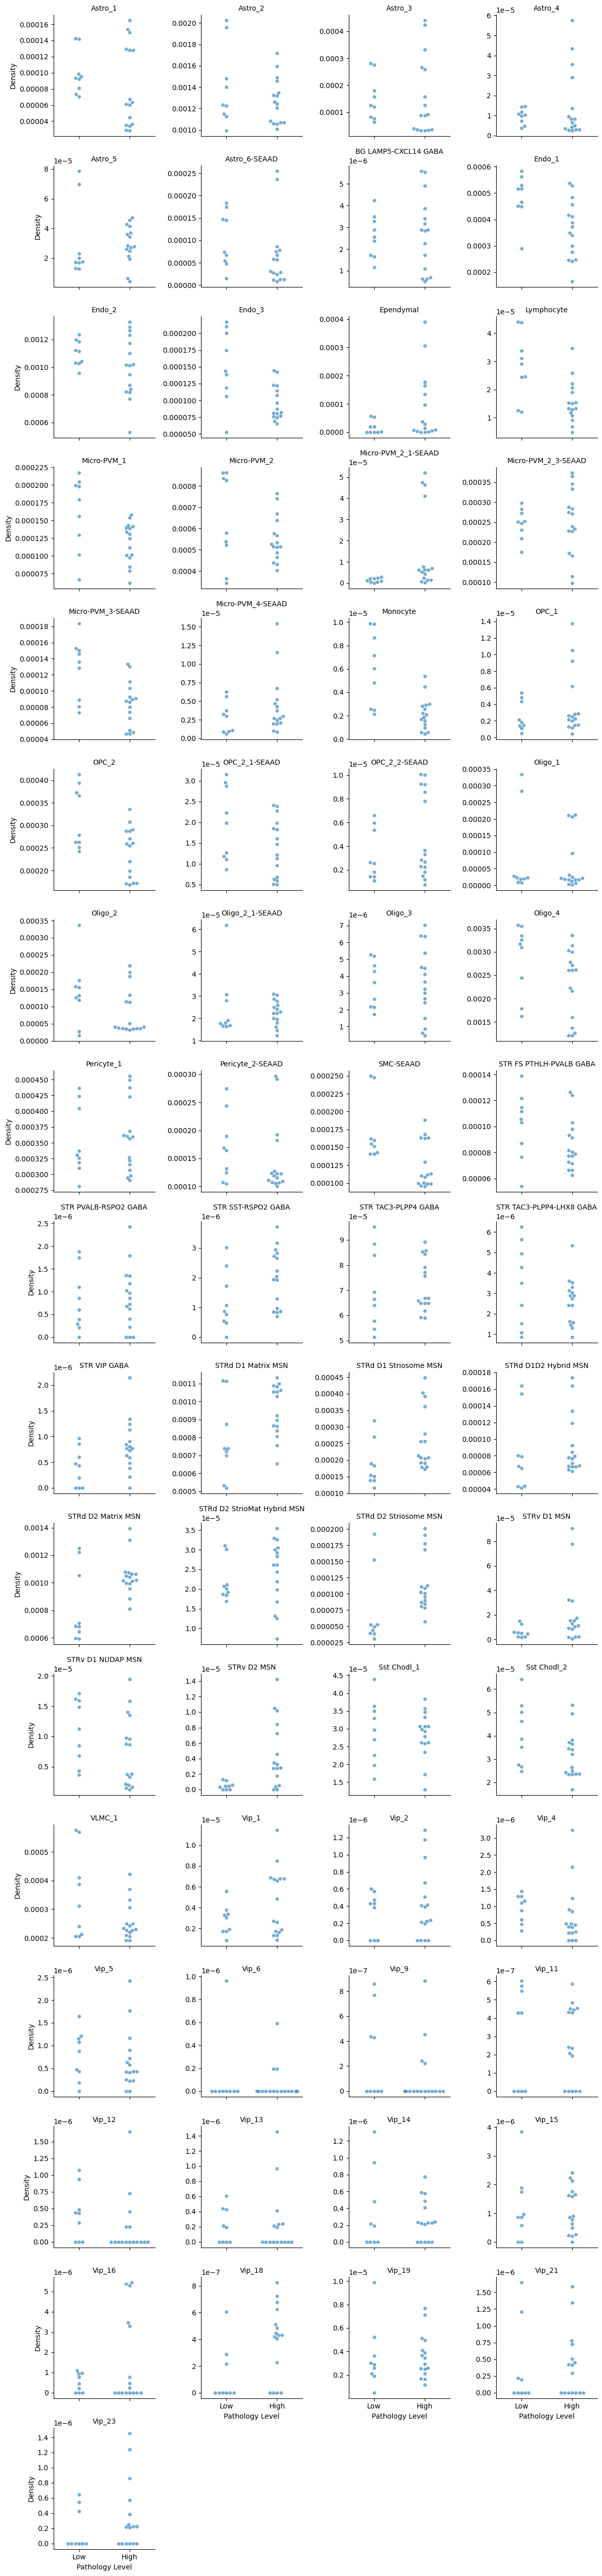

In [72]:
plot_df = density_df.melt(
    id_vars=['Pathology Level'],
    value_vars=y_vars,
    var_name='Neuron',
    value_name='Density'
)

g = sns.FacetGrid(plot_df, col='Neuron', col_wrap=4, height=3, sharey=False)
g.map(sns.swarmplot, 'Pathology Level', 'Density', alpha=0.6)
g.set_titles("{col_name}")

In [76]:
density_df = (
    (
    spatial_obs.groupby(['Donor ID', "barcode"])["Subclass"].value_counts() / 
    denominators
    ).unstack("Subclass")
)

/tmp/ipykernel_28391/4123099642.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby(['Donor ID', "barcode"])["Subclass"].value_counts() /


In [77]:
spatial_obs.groupby("Donor ID")

/tmp/ipykernel_28391/529213748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spatial_obs.groupby("Donor ID")


In [78]:
cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()

/tmp/ipykernel_28391/2692713578.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cps_obs = rna_obs.groupby(['Donor ID'])[['CPS', 'CPS_AT8', 'CPS_6E10']].first()


In [79]:
density_df.columns

CategoricalIndex(['Astrocyte', 'CN LAMP5-CXCL14 GABA', 'CN ST18 GABA',
                  'Endothelial', 'Ependymal', 'Microglia-PVM', 'OPC',
                  'Oligodendrocyte', 'STR D1 MSN', 'STR D2 MSN',
                  'STR Hybrid MSN', 'STR RSPO2 GABA', 'Sst Chodl', 'VLMC',
                  'Vip'],
                 categories=['Astrocyte', 'CN LAMP5-CXCL14 GABA', 'CN ST18 GABA', 'Endothelial', ..., 'STR RSPO2 GABA', 'Sst Chodl', 'VLMC', 'Vip'], ordered=False, dtype='category', name='Subclass')

In [80]:
density_df = density_df.reset_index()

In [81]:
density_df = density_df.merge(cps_obs, left_on = "Donor ID", right_index = True) 

In [82]:
density_df['Pathology Level'] = (density_df['CPS'] > 0.9).replace({True:"High", False:"Low"})

In [83]:
density_df.drop(columns = cps_obs.columns.tolist() + ['Pathology Level', 'Donor ID', 'barcode'])

,Astrocyte,CN LAMP5-CXCL14 GABA,CN ST18 GABA,Endothelial,Ependymal,Microglia-PVM,OPC,Oligodendrocyte,STR D1 MSN,STR D2 MSN,STR Hybrid MSN,STR RSPO2 GABA,Sst Chodl,VLMC,Vip
0,0.002366,0.000002,0.000215,0.001784,0.000002,0.000987,0.000426,0.001669,0.001436,0.001472,0.000180,0.000002,0.000108,0.001209,0.000024
1,0.002394,0.000003,0.000238,0.001791,0.000020,0.001022,0.000442,0.001841,0.001393,0.001406,0.000171,0.000002,0.000083,0.001252,0.000014
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,0.001886,0.000003,0.000140,0.001430,0.000177,0.001013,0.000300,0.003460,0.001140,0.001094,0.000078,0.000003,0.000060,0.001013,0.000011
222,0.001872,0.000004,0.000141,0.001374,0.000165,0.001050,0.000308,0.003449,0.001157,0.001094,0.000076,0.000002,0.000065,0.001045,0.000014
223,0.001640,0.000003,0.000141,0.001092,0.000134,0.000863,0.000266,0.003239,0.000923,0.000921,0.000076,0.000004,0.000041,0.000821,0.000016


In [84]:
plot_df = density_df.melt(
    id_vars=['Pathology Level'],
    value_vars=y_vars,
    var_name='Neuron',
    value_name='Density'
)

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Astro_1', 'Astro_2', 'Astro_3', 'Astro_4', 'Astro_5', 'Astro_6-SEAAD', 'BG LAMP5-CXCL14 GABA', 'Endo_1', 'Endo_2', 'Endo_3', 'Lymphocyte', 'Micro-PVM_1', 'Micro-PVM_2', 'Micro-PVM_2_1-SEAAD', 'Micro-PVM_2_3-SEAAD', 'Micro-PVM_3-SEAAD', 'Micro-PVM_4-SEAAD', 'Monocyte', 'OPC_1', 'OPC_2', 'OPC_2_1-SEAAD', 'OPC_2_2-SEAAD', 'Oligo_1', 'Oligo_2', 'Oligo_2_1-SEAAD', 'Oligo_3', 'Oligo_4', 'Pericyte_1', 'Pericyte_2-SEAAD', 'SMC-SEAAD', 'STR FS PTHLH-PVALB GABA', 'STR PVALB-RSPO2 GABA', 'STR SST-RSPO2 GABA', 'STR TAC3-PLPP4 GABA', 'STR TAC3-PLPP4-LHX8 GABA', 'STR VIP GABA', 'STRd D1 Matrix MSN', 'STRd D1 Striosome MSN', 'STRd D1D2 Hybrid MSN', 'STRd D2 Matrix MSN', 'STRd D2 StrioMat Hybrid MSN', 'STRd D2 Striosome MSN', 'STRv D1 MSN', 'STRv D1 NUDAP MSN', 'STRv D2 MSN', 'Sst Chodl_1', 'Sst Chodl_2', 'VLMC_1', 'Vip_1', 'Vip_2', 'Vip_4', 'Vip_5', 'Vip_6', 'Vip_9', 'Vip_11', 'Vip_12', 'Vip_13', 'Vip_14', 'Vip_15', 'V

In [85]:
density_df

,Donor ID,barcode,Astrocyte,CN LAMP5-CXCL14 GABA,CN ST18 GABA,Endothelial,Ependymal,Microglia-PVM,OPC,Oligodendrocyte,...,STR D2 MSN,STR Hybrid MSN,STR RSPO2 GABA,Sst Chodl,VLMC,Vip,CPS,CPS_AT8,CPS_6E10,Pathology Level
0,H19.33.004,1417642340,0.002366,0.000002,0.000215,0.001784,0.000002,0.000987,0.000426,0.001669,...,0.001472,0.000180,0.000002,0.000108,0.001209,0.000024,0.000000,0.000000,0.000000,Low
1,H19.33.004,1417642343,0.002394,0.000003,0.000238,0.001791,0.000020,0.001022,0.000442,0.001841,...,0.001406,0.000171,0.000002,0.000083,0.001252,0.000014,0.000000,0.000000,0.000000,Low
2,H19.33.004,1417642733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,Low
3,H19.33.004,1417642736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,Low
4,H19.33.004,1417642739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,H21.33.027,1417649142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.926583,0.662465,0.970979,High
221,H21.33.027,1417649441,0.001886,0.000003,0.000140,0.001430,0.000177,0.001013,0.000300,0.003460,...,0.001094,0.000078,0.000003,0.000060,0.001013,0.000011,0.926583,0.662465,0.970979,High
222,H21.33.027,1417649444,0.001872,0.000004,0.000141,0.001374,0.000165,0.001050,0.000308,0.003449,...,0.001094,0.000076,0.000002,0.000065,0.001045,0.000014,0.926583,0.662465,0.970979,High
223,H21.33.027,1417649447,0.001640,0.000003,0.000141,0.001092,0.000134,0.000863,0.000266,0.003239,...,0.000921,0.000076,0.000004,0.000041,0.000821,0.000016,0.926583,0.662465,0.970979,High


/opt/conda/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the swarmplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


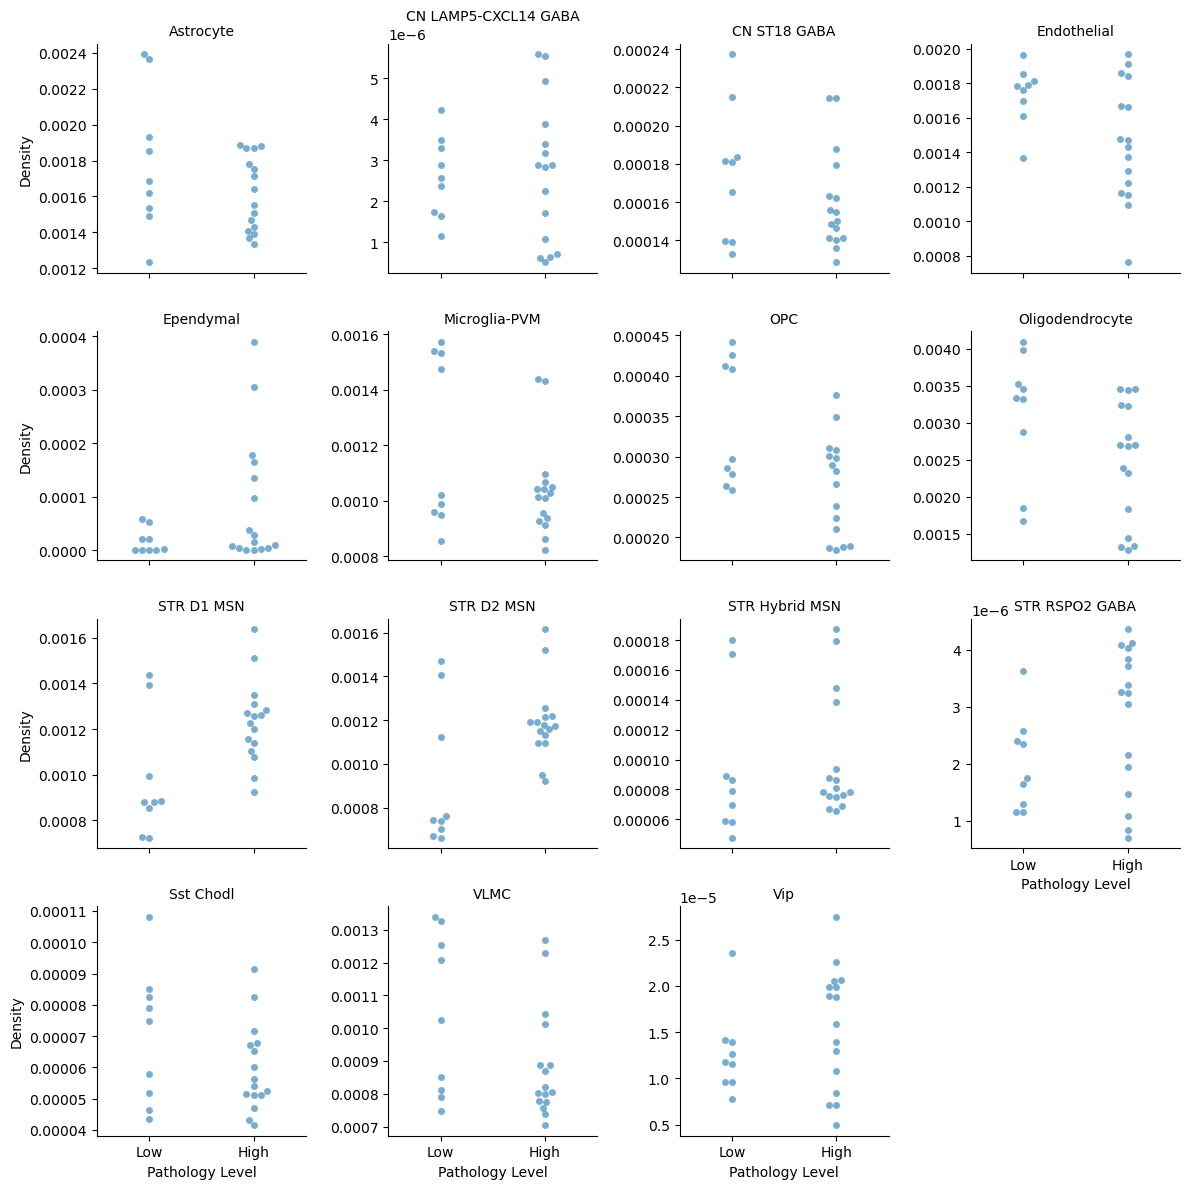

In [87]:
y_vars = density_df.drop(columns = ["Donor ID", "barcode", "CPS", "CPS_AT8", "CPS_6E10"]).columns
plot_df = density_df.melt(
    id_vars=['Pathology Level'],
    value_vars=y_vars,
    var_name='Neuron',
    value_name='Density'
)

g = sns.FacetGrid(plot_df, col='Neuron', col_wrap=4, height=3, sharey=False)
g.map(sns.swarmplot, 'Pathology Level', 'Density', alpha=0.6)
g.set_titles("{col_name}")